# 1. Introduction

## 1.1 Background

Machine unlearning studies whether a trained model can be updated so that selected training records no longer influence its behaviour. This notebook evaluates gradient-ascent unlearning on the Adult Income MLP using the same fixed data splits, deletion scenarios, baseline model and full-retraining references used in the previous notebooks.

Gradient-ascent unlearning deliberately increases the model loss on forget records. The basic form, often described as NegGrad, updates a fresh copy of the original baseline model by maximising loss on the forget set. The retain-regularised form, NegGrad+, combines this forget-side ascent with retain-side regularisation so that the model is discouraged from damaging records that should remain learned.

Both methods start from a fresh copy of the original baseline model for every deletion scenario. Increasing forget loss is not proof of unlearning, so the final evaluation compares the resulting model with the corresponding model retrained from scratch without the forget records.

## 1.2 Research Question

> To what extent does gradient-ascent unlearning provide evidence consistent with successful approximate machine unlearning while preserving predictive utility?

# 2. Experimental Setup

This section imports the required libraries, defines paths and loads the same processed Adult Income artefacts used by Notebook 3. No data cleaning, preprocessing, train/test splitting or forget-set construction is performed here.

## 2.1 Import Libraries

The notebook uses PyTorch for model updates, scikit-learn for evaluation metrics, scipy for distributional distances and pandas for result tables.

In [43]:
from pathlib import Path
import importlib
import inspect
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

PROJECT_CODE_DIR = Path("../..").resolve()
if str(PROJECT_CODE_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE_DIR))

import unlearning_evaluation

unlearning_evaluation = importlib.reload(unlearning_evaluation)
from unlearning_evaluation import (
    evaluate_unlearning_method,
    plot_forget_loss_ecdf,
    plot_forget_set_fidelity,
    plot_runtime_vs_forget_set_fidelity,
    plot_utility_delta,
)

## 2.2 Configuration

The same random seed and device-selection logic are used throughout the notebook. Paths mirror Notebook 3, but gradient-ascent outputs are written to their own result directory.

In [44]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [45]:
processed_adult_dir = Path("../../data/processed/adult")
baseline_models_dir = Path("../../models/adult")
baseline_metrics_dir = Path("../../results/metrics")
baseline_tables_dir = Path("../../results/tables")

full_retraining_dir = Path("../../results/full_retraining/adult")
forget_sets_dir = full_retraining_dir / "forget_sets"
retain_sets_dir = full_retraining_dir / "retain_sets"
retrained_models_dir = full_retraining_dir / "models"
retraining_metrics_dir = full_retraining_dir / "metrics"
retraining_tables_dir = full_retraining_dir / "tables"

gradient_ascent_dir = Path("../../results/gradient_ascent/adult")
gradient_ascent_models_dir = gradient_ascent_dir / "models"
gradient_ascent_metrics_dir = gradient_ascent_dir / "metrics"
gradient_ascent_tables_dir = gradient_ascent_dir / "tables"
gradient_ascent_figures_dir = gradient_ascent_dir / "figures"

for output_dir in [
    gradient_ascent_models_dir,
    gradient_ascent_metrics_dir,
    gradient_ascent_tables_dir,
    gradient_ascent_figures_dir,
]:
    output_dir.mkdir(parents=True, exist_ok=True)

In [46]:
# Notebook 4 consumes Notebook 1 and 2 artefacts rather than rebuilding them.
baseline_paths = {
    "x_train_raw": processed_adult_dir / "X_train_raw.csv",
    "x_val_raw": processed_adult_dir / "X_val_raw.csv",
    "x_test_raw": processed_adult_dir / "X_test_raw.csv",
    "x_train_processed": processed_adult_dir / "X_train_processed.csv",
    "x_val_processed": processed_adult_dir / "X_val_processed.csv",
    "x_test_processed": processed_adult_dir / "X_test_processed.csv",
    "y_train": processed_adult_dir / "y_train.csv",
    "y_val": processed_adult_dir / "y_val.csv",
    "y_test": processed_adult_dir / "y_test.csv",
    "baseline_model": baseline_models_dir / "adult_income_baseline_mlp.pt",
    "baseline_metrics": baseline_metrics_dir / "adult_baseline_mlp_metrics.csv",
    "baseline_predictions": baseline_tables_dir / "adult_baseline_mlp_test_predictions.csv",
}

# Scenario order is fixed so tables and figures stay comparable across notebooks.
scenario_names = [
    "s1_random_1_percent",
    "s2_random_5_percent",
    "s3_simulated_data_provider_withdrawal",
    "s4_random_10_percent",
    "s5_retention_expiry",
]

scenario_display_names = {
    "s1_random_1_percent": "Random 1%",
    "s2_random_5_percent": "Random 5%",
    "s3_simulated_data_provider_withdrawal": "Simulated Data Provider Withdrawal (~5%)",
    "s4_random_10_percent": "Random 10%",
    "s5_retention_expiry": "Simulated Retention Expiry",
}

# Expected counts catch accidental use of obsolete forget-set artefacts.
expected_forget_counts = {
    "s1_random_1_percent": 342,
    "s2_random_5_percent": 1709,
    "s3_simulated_data_provider_withdrawal": 1698,
    "s4_random_10_percent": 3419,
    "s5_retention_expiry": 5585,
}

scenario_file_prefixes = {
    "s1_random_1_percent": "s1",
    "s2_random_5_percent": "s2",
    "s3_simulated_data_provider_withdrawal": "s3",
    "s4_random_10_percent": "s4",
    "s5_retention_expiry": "s5",
}

forget_set_paths = {
    scenario: forget_sets_dir / f"{scenario}_forget_indices.npy"
    for scenario in scenario_names
}
retain_set_paths = {
    scenario: retain_sets_dir / f"{scenario}_retain_indices.npy"
    for scenario in scenario_names
}
retrained_model_paths = {
    scenario: retrained_models_dir / f"{prefix}_retrained_mlp.pt"
    for scenario, prefix in scenario_file_prefixes.items()
}

required_paths = {
    **baseline_paths,
    **{f"forget_{scenario}": path for scenario, path in forget_set_paths.items()},
    **{f"retain_{scenario}": path for scenario, path in retain_set_paths.items()},
    **{f"retrained_{scenario}": path for scenario, path in retrained_model_paths.items()},
}

# Failing early here avoids training against a partially regenerated artefact set.
missing_paths = [path for path in required_paths.values() if not path.exists()]
missing_paths = [path for path in required_paths.values() if not path.exists()]
if missing_paths:
    missing_text = "\n".join(map(str, missing_paths))
    raise FileNotFoundError(f"Missing required input artefacts:\n{missing_text}")

print("All required Notebook 1 and Notebook 2 outputs were found.")

All required Notebook 1 and Notebook 2 outputs were found.


## 2.3 Load Dataset

The processed data and labels are loaded from Notebook 1. Raw splits are loaded only to verify row-index alignment with the processed matrices.

In [47]:
# Raw splits are used for index context; processed splits are used for model input.
X_train_raw = pd.read_csv(baseline_paths["x_train_raw"], index_col=0)
X_val_raw = pd.read_csv(baseline_paths["x_val_raw"], index_col=0)
X_test_raw = pd.read_csv(baseline_paths["x_test_raw"], index_col=0)

# Processed matrices must match the 91-feature baseline checkpoint.
X_train_processed = pd.read_csv(baseline_paths["x_train_processed"], index_col=0)
X_val_processed = pd.read_csv(baseline_paths["x_val_processed"], index_col=0)
X_test_processed = pd.read_csv(baseline_paths["x_test_processed"], index_col=0)

y_train = pd.read_csv(baseline_paths["y_train"], index_col=0).squeeze("columns")
y_val = pd.read_csv(baseline_paths["y_val"], index_col=0).squeeze("columns")
y_test = pd.read_csv(baseline_paths["y_test"], index_col=0).squeeze("columns")

# Index checks ensure raw, processed and label rows still refer to the same records.
assert X_train_raw.index.equals(X_train_processed.index)
assert X_val_raw.index.equals(X_val_processed.index)
assert X_test_raw.index.equals(X_test_processed.index)
assert X_train_processed.index.equals(y_train.index)
assert X_val_processed.index.equals(y_val.index)
assert X_test_processed.index.equals(y_test.index)
assert X_train_processed.shape == (34189, 91)

pd.DataFrame(
    [
        {
            "split": "train",
            "rows": X_train_processed.shape[0],
            "features": X_train_processed.shape[1],
            "labels": len(y_train),
        },
        {
            "split": "validation",
            "rows": X_val_processed.shape[0],
            "features": X_val_processed.shape[1],
            "labels": len(y_val),
        },
        {
            "split": "test",
            "rows": X_test_processed.shape[0],
            "features": X_test_processed.shape[1],
            "labels": len(y_test),
        },
    ]
)

,split,rows,features,labels
0,train,34189,91,34189
1,validation,7326,91,7326
2,test,7327,91,7327


## 2.4 Load Models

The original baseline checkpoint and fully retrained reference checkpoints are loaded from previous notebooks. The MLP class is defined here so that checkpoints can be reconstructed consistently.

In [48]:
# The architecture is reconstructed exactly so Notebook 1 and 2 checkpoints load safely.
class AdultIncomeMLP(nn.Module):
    """Small MLP for binary Adult Income classification."""

    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1),
        )

    def forward(self, features):
        return self.network(features)


input_dim = X_train_processed.shape[1]
criterion = nn.BCEWithLogitsLoss()


# Checkpoint metadata controls input size rather than hard-coded feature counts.
def load_model_from_checkpoint(checkpoint):
    model = AdultIncomeMLP(input_dim=checkpoint["input_dim"]).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return model


baseline_checkpoint = torch.load(
    baseline_paths["baseline_model"],
    map_location=device,
    weights_only=True,
)
retrained_checkpoints = {
    scenario: torch.load(path, map_location=device, weights_only=False)
    for scenario, path in retrained_model_paths.items()
}
baseline_metrics = pd.read_csv(baseline_paths["baseline_metrics"])
# Baseline predictions are reused for agreement and probability-shift comparisons.
baseline_predictions = pd.read_csv(baseline_paths["baseline_predictions"])

# The baseline model is kept unchanged as the starting point and comparison model.
baseline_model = load_model_from_checkpoint(baseline_checkpoint)
baseline_model.eval()

assert baseline_checkpoint["input_dim"] == input_dim
assert baseline_checkpoint["input_dim"] == 91
assert baseline_checkpoint["random_seed"] == RANDOM_SEED

checkpoint_rows = []
for scenario, checkpoint in retrained_checkpoints.items():
    assert checkpoint["scenario"] == scenario
    assert checkpoint["input_dim"] == input_dim
    checkpoint_rows.append(
        {
            "scenario": scenario,
            "display_name": scenario_display_names[scenario],
            "input_dim": checkpoint["input_dim"],
            "retain_count": checkpoint["retain_count"],
            "runtime_seconds": checkpoint["runtime_seconds"],
        }
    )

pd.DataFrame(checkpoint_rows)

,scenario,display_name,input_dim,retain_count,runtime_seconds
0,s1_random_1_percent,Random 1%,91,33847,6.158163
1,s2_random_5_percent,Random 5%,91,32480,6.309743
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),91,32491,4.582676
3,s4_random_10_percent,Random 10%,91,30770,5.082448
4,s5_retention_expiry,Simulated Retention Expiry,91,28604,5.083569


## 2.5 Deletion Scenarios

The notebook uses the five current deletion scenarios from Notebook 2 and Notebook 3. Each scenario has a matching forget set and retain set, and the fully retrained model for that scenario is the empirical reference for final evaluation.

In [49]:
# Forget and retain indices are loaded exactly as defined by full retraining.
forget_indices = {scenario: np.load(path) for scenario, path in forget_set_paths.items()}
retain_indices = {scenario: np.load(path) for scenario, path in retain_set_paths.items()}

training_index = set(X_train_processed.index.to_numpy())
subset_rows = []

# Disjointness checks prevent accidental overlap between deletion and retain records.
for scenario in scenario_names:
    scenario_forget = set(forget_indices[scenario])
    scenario_retain = set(retain_indices[scenario])
    assert scenario_forget.isdisjoint(scenario_retain)
    # Their union must reconstruct the original training set exactly.
    assert scenario_forget.union(scenario_retain) == training_index
    assert len(scenario_forget) == expected_forget_counts[scenario]
    assert retrained_checkpoints[scenario]["retain_count"] == len(scenario_retain)
    subset_rows.append(
        {
            "scenario": scenario,
            "display_name": scenario_display_names[scenario],
            "forget_count": len(scenario_forget),
            "retain_count": len(scenario_retain),
            "forget_percentage": len(scenario_forget) / len(training_index) * 100,
            "training_count": len(training_index),
        }
    )

# This compact table is the reader-facing scenario manifest.
scenario_summary = pd.DataFrame(subset_rows)
scenario_summary

,scenario,display_name,forget_count,retain_count,forget_percentage,training_count
0,s1_random_1_percent,Random 1%,342,33847,1.000322,34189
1,s2_random_5_percent,Random 5%,1709,32480,4.998684,34189
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),1698,32491,4.966510,34189
3,s4_random_10_percent,Random 10%,3419,30770,10.000292,34189
4,s5_retention_expiry,Simulated Retention Expiry,5585,28604,16.335664,34189


# 3. Gradient-Ascent Unlearning

This section runs gradient-ascent unlearning from a fresh baseline copy for every scenario. Both basic NegGrad and retain-regularised NegGrad+ are evaluated using a predeclared validation-based selection rule.

## 3.1 Gradient-Ascent Approach

Ordinary training minimises prediction loss on training records. NegGrad reverses that direction on the forget set by minimising the negative forget loss, which maximises the model's error on those records. NegGrad+ adds retain-side regularisation by minimising `-forget_loss + retain_weight * retain_loss`, so the method still pushes away from forget records while discouraging damage to retain records.

The final selected model is not judged by forget-loss increase alone. It is evaluated against the full-retraining reference to determine whether the update moved the model towards the behaviour expected from training without the forget records.

## 3.2 Gradient-Ascent Configuration

The primary experiment processes the complete forget set during every gradient-ascent epoch. Candidate learning rates and retain weights are declared before training, and model selection uses validation utility constraints rather than test-set or full-retraining outputs.

In [50]:
# The primary experiment uses full forget-set coverage with a small epoch budget.
GRADIENT_ASCENT_MAX_EPOCHS = 10 # chosen as quite conservative
GRADIENT_ASCENT_BATCH_SIZE = 256
GRADIENT_ASCENT_SEED_OFFSET = 900
GRADIENT_CLIP_NORM = 2.0
EARLY_STOPPING_PATIENCE = 2
MIN_FORGET_LOSS_IMPROVEMENT = 1e-4

# The grid stays deliberately small because ascent can quickly damage utility.
#NegGrad gets 3 candidates as it only tunes lr 

# NegGrad+ has lr and retain weight - both tested with fewer values 

NEGGRAD_LEARNING_RATES = [1e-5, 5e-5, 1e-4]
NEGGRAD_PLUS_LEARNING_RATES = [1e-5, 5e-5]
RETAIN_REGULARISATION_WEIGHTS = [0.1, 0.5]

# Tolerances define utility protection before any test-set evaluation is used.
VALIDATION_LOSS_INCREASE_TOLERANCE = 0.05
VALIDATION_ACCURACY_DROP_TOLERANCE = 0.03
VALIDATION_F1_DROP_TOLERANCE = 0.03
VALIDATION_AUROC_DROP_TOLERANCE = 0.02

hyperparameter_grid = []
for learning_rate in NEGGRAD_LEARNING_RATES:
    hyperparameter_grid.append(
        {
            "method": "NegGrad",
            "learning_rate": learning_rate,
            "retain_weight": 0.0,
        }
    )
for learning_rate in NEGGRAD_PLUS_LEARNING_RATES:
    for retain_weight in RETAIN_REGULARISATION_WEIGHTS:
        hyperparameter_grid.append(
            {
                "method": "NegGrad+",
                "learning_rate": learning_rate,
                "retain_weight": retain_weight,
            }
        )

pd.DataFrame(hyperparameter_grid)

,method,learning_rate,retain_weight
0,NegGrad,0.00001,0.0
1,NegGrad,0.00005,0.0
2,NegGrad,0.00010,0.0
3,NegGrad+,0.00001,0.1
4,NegGrad+,0.00001,0.5
5,NegGrad+,0.00005,0.1
6,NegGrad+,0.00005,0.5


## 3.3 Gradient-Ascent Helper Functions

These helpers create deterministic data loaders, evaluate models on fixed subsets, run NegGrad and NegGrad+ candidates and apply the validation-based selection rule. Every candidate starts from the original baseline weights.

In [51]:
def create_tensor_dataset(features, labels):
    feature_tensor = torch.tensor(
        features.to_numpy(dtype=np.float32),
        dtype=torch.float32,
    )
    label_tensor = torch.tensor(
        labels.to_numpy(dtype=np.float32).reshape(-1, 1),
        dtype=torch.float32,
    )
    return TensorDataset(feature_tensor, label_tensor)


# Seeded loaders make candidate searches reproducible while preserving row labels.
def create_data_loader(features, labels, batch_size=256, shuffle=False, seed=None):
    dataset = create_tensor_dataset(features, labels)
    generator = None
    if shuffle:
        generator = torch.Generator()
        generator.manual_seed(RANDOM_SEED if seed is None else seed)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, generator=generator)


# Every candidate starts from the same unchanged baseline weights.
def clone_baseline_model():
    model = AdultIncomeMLP(input_dim=input_dim).to(device)
    model.load_state_dict(
        {
            key: value.to(device)
            for key, value in baseline_checkpoint["model_state_dict"].items()
        }
    )
    return model


# CPU snapshots keep checkpoint copies independent of later GPU/MPS updates.
def state_dict_to_cpu(model):
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }


# Prediction batches are deterministic because evaluation never shuffles records.
def predict_with_model(model, features, batch_size=256):
    dummy_labels = pd.Series(np.zeros(len(features)), index=features.index)
    data_loader = create_data_loader(features, dummy_labels, batch_size=batch_size, shuffle=False)
    model.eval()
    probabilities = []
    with torch.no_grad():
        for batch_features, _ in data_loader:
            batch_features = batch_features.to(device)
            logits = model(batch_features)
            probabilities.extend(torch.sigmoid(logits).cpu().numpy().ravel())
    probabilities = np.asarray(probabilities)
    predictions = (probabilities >= 0.5).astype(int)
    return probabilities, predictions


# Forget-loss changes are measured against the candidate's own baseline clone.
def calculate_average_loss(model, features, labels, batch_size=256):
    data_loader = create_data_loader(features, labels, batch_size=batch_size, shuffle=False)
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch_features, batch_labels in data_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            loss = criterion(model(batch_features), batch_labels)
            total_loss += loss.item() * batch_features.size(0)
    return total_loss / len(data_loader.dataset)


# Balanced accuracy is included because Adult Income is class-imbalanced.
def calculate_binary_metrics(y_true, y_pred, y_prob):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }
    metrics["roc_auc"] = roc_auc_score(y_true, y_prob) if pd.Series(y_true).nunique() > 1 else np.nan
    return metrics


def evaluate_subset(model, features, labels, batch_size=256):
    probabilities, predictions = predict_with_model(model, features, batch_size=batch_size)
    metrics = calculate_binary_metrics(labels, predictions, probabilities)
    metrics["loss"] = calculate_average_loss(model, features, labels, batch_size=batch_size)
    metrics["probabilities"] = probabilities
    metrics["predictions"] = predictions
    return metrics


baseline_validation = evaluate_subset(baseline_model, X_val_processed, y_val)
baseline_validation_constraints = {
    "loss_max": baseline_validation["loss"] + VALIDATION_LOSS_INCREASE_TOLERANCE,
    "accuracy_min": baseline_validation["accuracy"] - VALIDATION_ACCURACY_DROP_TOLERANCE,
    "f1_min": baseline_validation["f1_score"] - VALIDATION_F1_DROP_TOLERANCE,
    "auroc_min": baseline_validation["roc_auc"] - VALIDATION_AUROC_DROP_TOLERANCE,
}

baseline_validation_table = pd.DataFrame([baseline_validation_constraints])
baseline_validation_table

,loss_max,accuracy_min,f1_min,auroc_min
0,0.351041,0.831043,0.658494,0.896579


These values define the acceptance boundaries for every gradient-ascent candidate. Validation loss must stay before 0.351, and validation accuracy, F1 and AUROC must stay above 0.831, 0.658, and 0.897 respectively. Each threshold is the baseline mdoels own validation performance adjusted by a small pre declared tolerence. A candidate epoch is only eligible for selection if it satisfies all 4. 

**Gradient-Ascent Training Loop and Candidate Selection**

This trains one single candidate and decides which of its epochs is the best one to keep. It gets called 7 times per scenario - one for each candidate in the grid. 

In [52]:
# Retain batches are recycled when a forget epoch has more batches than the retain iterator.
def get_next_batch(iterator, loader):
    try:
        return next(iterator), iterator
    except StopIteration:
        iterator = iter(loader)
        return next(iterator), iterator


def validation_is_acceptable(validation_metrics):
    return (
        validation_metrics["loss"] <= baseline_validation_constraints["loss_max"]
        and validation_metrics["accuracy"] >= baseline_validation_constraints["accuracy_min"]
        and validation_metrics["f1_score"] >= baseline_validation_constraints["f1_min"]
        and validation_metrics["roc_auc"] >= baseline_validation_constraints["auroc_min"]
    )


def validation_safety_score(validation_metrics):
    # The safety score ranks invalid candidates by how little they violate validation constraints.
    loss_excess = max(0.0, validation_metrics["loss"] - baseline_validation_constraints["loss_max"])
    accuracy_deficit = max(0.0, baseline_validation_constraints["accuracy_min"] - validation_metrics["accuracy"])
    f1_deficit = max(0.0, baseline_validation_constraints["f1_min"] - validation_metrics["f1_score"])
    auroc_deficit = max(0.0, baseline_validation_constraints["auroc_min"] - validation_metrics["roc_auc"])
    return -(loss_excess + accuracy_deficit + f1_deficit + auroc_deficit)


def train_gradient_ascent_candidate(
    scenario,
    method,
    learning_rate,
    retain_weight,
    scenario_seed,
):
    X_forget = X_train_processed.loc[forget_indices[scenario]]
    y_forget = y_train.loc[forget_indices[scenario]]
    X_retain = X_train_processed.loc[retain_indices[scenario]]
    y_retain = y_train.loc[retain_indices[scenario]]

    # The primary method iterates over the complete forget set each epoch.
    forget_loader = create_data_loader(
        X_forget,
        y_forget,
        batch_size=GRADIENT_ASCENT_BATCH_SIZE,
        shuffle=True,
        seed=scenario_seed,
    )
    retain_loader = create_data_loader(
        X_retain,
        y_retain,
        batch_size=GRADIENT_ASCENT_BATCH_SIZE,
        shuffle=True,
        seed=scenario_seed + 100,
    )

    model = clone_baseline_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # This baseline loss anchors the candidate-specific forget-loss increase.
    baseline_forget_loss = calculate_average_loss(
        model,
        X_forget,
        y_forget,
        batch_size=GRADIENT_ASCENT_BATCH_SIZE,
    )

    # Epoch 0 stores the unchanged baseline control for sweep comparisons.
    checkpoints = {0: state_dict_to_cpu(model)}
    history_rows = []
    best_state = state_dict_to_cpu(model)
    best_selection_score = -np.inf
    best_epoch = 0
    best_valid = False
    best_forget_loss_change = 0.0
    epochs_without_improvement = 0
    cumulative_optimizer_steps = 0
    cumulative_training_seconds = 0.0
    early_stopping_reason = "completed"

    for epoch in range(1, GRADIENT_ASCENT_MAX_EPOCHS + 1):
        model.train()
        retain_iterator = iter(retain_loader)
        running_forget_loss = 0.0
        running_retain_loss = 0.0
        running_objective = 0.0
        examples_seen = 0
        epoch_training_start = time.perf_counter()

        for forget_features, forget_labels in forget_loader:
            forget_features = forget_features.to(device)
            forget_labels = forget_labels.to(device)
            optimizer.zero_grad()
            forget_loss = criterion(model(forget_features), forget_labels)
            retain_loss = torch.tensor(0.0, device=device)

            # NegGrad+ pulls a retain batch here to penalise damage to retained data.
            if method == "NegGrad+":
                (retain_features, retain_labels), retain_iterator = get_next_batch(
                    retain_iterator,
                    retain_loader,
                )
                retain_features = retain_features.to(device)
                retain_labels = retain_labels.to(device)
                retain_loss = criterion(model(retain_features), retain_labels)

            # The objective maximises forget loss while optionally regularising retain loss.
            objective = -forget_loss + retain_weight * retain_loss
            objective.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
            optimizer.step()

            batch_size = forget_features.size(0)
            running_forget_loss += forget_loss.item() * batch_size
            running_retain_loss += retain_loss.item() * batch_size
            running_objective += objective.item() * batch_size
            examples_seen += batch_size
            cumulative_optimizer_steps += 1

        cumulative_training_seconds += time.perf_counter() - epoch_training_start
        # Candidate selection uses validation data, not test or full-retraining outputs.
        validation_metrics = evaluate_subset(model, X_val_processed, y_val, batch_size=GRADIENT_ASCENT_BATCH_SIZE)
        current_forget_loss = calculate_average_loss(model, X_forget, y_forget, batch_size=GRADIENT_ASCENT_BATCH_SIZE)
        forget_loss_change = current_forget_loss - baseline_forget_loss
        selection_valid = validation_is_acceptable(validation_metrics)
        safety_score = validation_safety_score(validation_metrics)
        selection_score = forget_loss_change if selection_valid else -np.inf

        # Every completed epoch is stored so the selected checkpoint can be restored exactly.
        checkpoints[epoch] = state_dict_to_cpu(model)
        history_rows.append(
            {
                "scenario": scenario,
                "display_name": scenario_display_names[scenario],
                "method": method,
                "learning_rate": learning_rate,
                "retain_weight": retain_weight,
                "epoch": epoch,
                "forget_train_loss": running_forget_loss / examples_seen,
                "retain_train_loss": running_retain_loss / examples_seen,
                "objective": running_objective / examples_seen,
                "forget_loss": current_forget_loss,
                "forget_loss_change": forget_loss_change,
                "validation_loss": validation_metrics["loss"],
                "validation_accuracy": validation_metrics["accuracy"],
                "validation_f1": validation_metrics["f1_score"],
                "validation_balanced_accuracy": validation_metrics["balanced_accuracy"],
                "validation_auroc": validation_metrics["roc_auc"],
                "selection_valid": selection_valid,
                "validation_safety_score": safety_score,
                "cumulative_optimizer_steps": cumulative_optimizer_steps,
                "runtime_seconds": cumulative_training_seconds,
                "scenario_seed": scenario_seed,
            }
        )

        candidate_better = (
            selection_valid and selection_score > best_selection_score
        ) or (
            not best_valid and not selection_valid and safety_score > best_selection_score
        )
        # Candidate checkpoints are selected using validation constraints and forget-loss movement only.
        if candidate_better:
            best_state = state_dict_to_cpu(model)
            best_epoch = epoch
            best_valid = selection_valid
            best_selection_score = selection_score if selection_valid else safety_score
            best_forget_loss_change = forget_loss_change

        # Combined stagnation check: an epoch counts as exactly one
        # non-improving epoch if it either failed to become the new best,
        # or failed to grow forget loss enough, or both. Previously these
        # were two separate increments and could add 2 in a single epoch.
        forget_loss_stagnant = (
            epoch > 1
            and forget_loss_change < (best_forget_loss_change + MIN_FORGET_LOSS_IMPROVEMENT)
        )
        if candidate_better and not forget_loss_stagnant:
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Early stopping prevents extra ascent steps after forget loss stops improving.
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            early_stopping_reason = "no_validation_acceptable_forget_loss_improvement"
            break

    model.load_state_dict({key: value.to(device) for key, value in best_state.items()})
    history = pd.DataFrame(history_rows)
    return {
        "scenario": scenario,
        "display_name": scenario_display_names[scenario],
        "method": method,
        "learning_rate": learning_rate,
        "retain_weight": retain_weight,
        "model": model,
        "history": history,
        "checkpoint_states": checkpoints,
        "selected_state_dict": best_state,
        "selected_epoch": best_epoch,
        "configured_max_epochs": GRADIENT_ASCENT_MAX_EPOCHS,
        "actual_epochs_completed": int(history["epoch"].max()) if not history.empty else 0,
        "optimizer_steps": cumulative_optimizer_steps,
        "runtime_seconds": cumulative_training_seconds,
        "forget_loss_change": best_forget_loss_change,
        "selection_valid": best_valid,
        "early_stopping_reason": early_stopping_reason,
        "scenario_seed": scenario_seed,
    }

**Candidate Selection for a Scenario**

This function picks the best candidate out of all 7 that were run for a single scenario 

In [53]:
def select_candidate_for_scenario(candidate_results):
    final_rows = []
    for candidate in candidate_results:
        history = candidate["history"]
        # The selected row may be earlier than the final epoch after early stopping.
        selected_rows = history[history["epoch"] == candidate["selected_epoch"]]
        selected_row = selected_rows.iloc[-1] if not selected_rows.empty else history.iloc[-1]
        final_rows.append(
            {
                "candidate_index": len(final_rows),
                "scenario": candidate["scenario"],
                "display_name": candidate["display_name"],
                "method": candidate["method"],
                "learning_rate": candidate["learning_rate"],
                "retain_weight": candidate["retain_weight"],
                "selected_epoch": candidate["selected_epoch"],
                "actual_epochs_completed": candidate["actual_epochs_completed"],
                "optimizer_steps": candidate["optimizer_steps"],
                "runtime_seconds": candidate["runtime_seconds"],
                "forget_loss_change": candidate["forget_loss_change"],
                "selection_valid": candidate["selection_valid"],
                "validation_loss": selected_row["validation_loss"],
                "validation_accuracy": selected_row["validation_accuracy"],
                "validation_f1": selected_row["validation_f1"],
                "validation_balanced_accuracy": selected_row["validation_balanced_accuracy"],
                "validation_auroc": selected_row["validation_auroc"],
                "validation_safety_score": selected_row["validation_safety_score"],
                "early_stopping_reason": candidate["early_stopping_reason"],
            }
        )
    # The candidate table is saved so hyperparameter selection remains auditable.
    candidate_table = pd.DataFrame(final_rows)
    valid_candidates = candidate_table[candidate_table["selection_valid"]]
    # Valid candidates are ranked by forget-loss increase; invalid runs fall back to validation safety.
    if not valid_candidates.empty:
        selected_index = valid_candidates["forget_loss_change"].idxmax()
    else:
        selected_index = candidate_table["validation_safety_score"].idxmax()
    selected_candidate_index = int(candidate_table.loc[selected_index, "candidate_index"])
    return candidate_results[selected_candidate_index], candidate_table

## 3.4 Apply Gradient Ascent

The same predeclared candidate grid is applied to every scenario. Detailed search results are saved, while the notebook displays a concise selected-configuration table.

In [54]:
gradient_ascent_results = {}
all_candidate_rows = []
all_history_frames = []
all_candidate_results = {}

# Scenario-specific seeds keep candidate searches reproducible and independent.
for scenario_position, scenario in enumerate(scenario_names):
    scenario_seed = RANDOM_SEED + GRADIENT_ASCENT_SEED_OFFSET + scenario_position
    candidate_results = []
    # Every candidate is trained independently from a fresh baseline clone.
    for candidate in hyperparameter_grid:
        result = train_gradient_ascent_candidate(
            scenario=scenario,
            method=candidate["method"],
            learning_rate=candidate["learning_rate"],
            retain_weight=candidate["retain_weight"],
            scenario_seed=scenario_seed,
        )
        candidate_results.append(result)
        history = result["history"].copy()
        history["candidate_method"] = result["method"]
        history["candidate_learning_rate"] = result["learning_rate"]
        history["candidate_retain_weight"] = result["retain_weight"]
        all_history_frames.append(history)

    # Selection is completed before any final test-set or retrained-model comparison.
    selected_result, candidate_table = select_candidate_for_scenario(candidate_results)
    gradient_ascent_results[scenario] = selected_result
    all_candidate_results[scenario] = candidate_results
    all_candidate_rows.append(candidate_table)

# The full grid is retained even though only selected rows are displayed.
hyperparameter_search_results = pd.concat(all_candidate_rows, ignore_index=True)
gradient_ascent_history = pd.concat(all_history_frames, ignore_index=True)

selected_configuration_rows = []
for scenario, result in gradient_ascent_results.items():
    history = result["history"]
    selected_row = history[history["epoch"] == result["selected_epoch"]].iloc[-1]
    selected_configuration_rows.append(
        {
            "scenario": scenario,
            "display_name": scenario_display_names[scenario],
            "selected_method": result["method"],
            "learning_rate": result["learning_rate"],
            "retain_weight": result["retain_weight"],
            "configured_max_epochs": result["configured_max_epochs"],
            "actual_epochs_completed": result["actual_epochs_completed"],
            "selected_epoch": result["selected_epoch"],
            "optimizer_steps": result["optimizer_steps"],
            "forget_loss_change": result["forget_loss_change"],
            "validation_loss": selected_row["validation_loss"],
            "validation_accuracy": selected_row["validation_accuracy"],
            "validation_f1": selected_row["validation_f1"],
            "validation_balanced_accuracy": selected_row["validation_balanced_accuracy"],
            "validation_auroc": selected_row["validation_auroc"],
            "runtime_seconds": result["runtime_seconds"],
            "selection_valid": result["selection_valid"],
            "early_stopping_reason": result["early_stopping_reason"],
        }
    )

selected_configurations = pd.DataFrame(selected_configuration_rows)
selected_configurations

,scenario,display_name,selected_method,learning_rate,retain_weight,configured_max_epochs,actual_epochs_completed,selected_epoch,optimizer_steps,forget_loss_change,validation_loss,validation_accuracy,validation_f1,validation_balanced_accuracy,validation_auroc,runtime_seconds,selection_valid,early_stopping_reason
0,s1_random_1_percent,Random 1%,NegGrad,0.0001,0.0,10,3,3,6,0.001783,0.301217,0.860633,0.690137,0.787965,0.916526,0.025172,True,no_validation_acceptable_forget_loss_improvement
1,s2_random_5_percent,Random 5%,NegGrad,0.0001,0.0,10,3,3,21,0.002608,0.301675,0.861179,0.694503,0.792039,0.916529,0.083944,True,no_validation_acceptable_forget_loss_improvement
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),NegGrad,0.0001,0.0,10,3,3,21,0.002242,0.301651,0.861452,0.694553,0.791827,0.916481,0.083554,True,no_validation_acceptable_forget_loss_improvement
3,s4_random_10_percent,Random 10%,NegGrad,0.0001,0.0,10,3,3,42,0.002156,0.301560,0.861179,0.692842,0.790279,0.916500,0.153832,True,no_validation_acceptable_forget_loss_improvement
4,s5_retention_expiry,Simulated Retention Expiry,NegGrad,0.0001,0.0,10,3,3,66,0.010139,0.306356,0.859951,0.706354,0.806481,0.915938,0.234196,True,no_validation_acceptable_forget_loss_improvement


## 3.5 Gradient-Ascent Summary

The selected table reports one configuration per scenario. A false `selection_valid` flag means no candidate satisfied all validation-utility constraints, so the safest validation-utility candidate was retained and should not be presented as successful unlearning.

In [55]:
selected_configurations

,scenario,display_name,selected_method,learning_rate,retain_weight,configured_max_epochs,actual_epochs_completed,selected_epoch,optimizer_steps,forget_loss_change,validation_loss,validation_accuracy,validation_f1,validation_balanced_accuracy,validation_auroc,runtime_seconds,selection_valid,early_stopping_reason
0,s1_random_1_percent,Random 1%,NegGrad,0.0001,0.0,10,3,3,6,0.001783,0.301217,0.860633,0.690137,0.787965,0.916526,0.025172,True,no_validation_acceptable_forget_loss_improvement
1,s2_random_5_percent,Random 5%,NegGrad,0.0001,0.0,10,3,3,21,0.002608,0.301675,0.861179,0.694503,0.792039,0.916529,0.083944,True,no_validation_acceptable_forget_loss_improvement
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),NegGrad,0.0001,0.0,10,3,3,21,0.002242,0.301651,0.861452,0.694553,0.791827,0.916481,0.083554,True,no_validation_acceptable_forget_loss_improvement
3,s4_random_10_percent,Random 10%,NegGrad,0.0001,0.0,10,3,3,42,0.002156,0.301560,0.861179,0.692842,0.790279,0.916500,0.153832,True,no_validation_acceptable_forget_loss_improvement
4,s5_retention_expiry,Simulated Retention Expiry,NegGrad,0.0001,0.0,10,3,3,66,0.010139,0.306356,0.859951,0.706354,0.806481,0.915938,0.234196,True,no_validation_acceptable_forget_loss_improvement


**Findings**

The results confir that gradient ascent converges to the same result, regardless of how many epochs are offered. Each scenario independantly chooses the same configurations ( NegGrad, Lr = 0.0001, no retain set protection) by epoch 3 with a budget of 10, showing that at this point the model stops improving on the forget set. Validation performance stays close to the original baseline throughout. This table confirms that the process is stable and safe but does not prove unlearning.

# 4. Evaluation Setup

This section mirrors Notebook 3’s evaluation setup. It generates predictions, defines classification and MIA helpers, trains the same positive-control model and initialises models for the later evaluation sections.

## 4.1 Generate Test Predictions

Test predictions are generated once for each selected gradient-ascent model using the unchanged test set. These predictions are reused by the utility and comparison sections.

In [56]:
prediction_rows = []
for scenario, result in gradient_ascent_results.items():
    probabilities, predictions = predict_with_model(result["model"], X_test_processed)
    for original_index, y_true, y_prob, y_pred in zip(
        X_test_processed.index,
        y_test,
        probabilities,
        predictions,
    ):
        prediction_rows.append(
            {
                "scenario": scenario,
                "display_name": scenario_display_names[scenario],
                "record_index": int(original_index),
                "y_true": int(y_true),
                "y_prob": float(y_prob),
                "y_pred": int(y_pred),
            }
        )

gradient_ascent_predictions = pd.DataFrame(prediction_rows)
gradient_ascent_predictions.head()

,scenario,display_name,record_index,y_true,y_prob,y_pred
0,s1_random_1_percent,Random 1%,4683,0,0.211328,0
1,s1_random_1_percent,Random 1%,18705,0,0.122471,0
2,s1_random_1_percent,Random 1%,14668,0,0.039314,0
3,s1_random_1_percent,Random 1%,4094,1,0.012646,0
4,s1_random_1_percent,Random 1%,34747,0,0.024105,0


5 examples predictions for Scenario 1. 4 out of 5 of these are correct. Row 3 is a very confident wrong guess, stating there is only a 1.3% chance that this record = >50K. 

## 4.2 Classification Evaluation Helper

The helper below calculates scenario-level test metrics, classification reports and confusion matrices from the saved prediction table.

In [57]:
# This helper keeps per-scenario metrics and plots consistent across S1-S5.
def evaluate_scenario_predictions(scenario, predictions_df):
    scenario_predictions = predictions_df[predictions_df["scenario"] == scenario].copy()
    metrics = calculate_binary_metrics(
        scenario_predictions["y_true"],
        scenario_predictions["y_pred"],
        scenario_predictions["y_prob"],
    )
    metrics = {
        "scenario": scenario,
        "display_name": scenario_display_names[scenario],
        **metrics,
    }
    # Classification reports expose class-specific behaviour hidden by accuracy.
    report = classification_report(
        scenario_predictions["y_true"],
        scenario_predictions["y_pred"],
        output_dict=True,
        zero_division=0,
    )
    report_rows = []
    for label, values in report.items():
        if isinstance(values, dict):
            report_rows.append({"scenario": scenario, "label": label, **values})
    matrix = confusion_matrix(scenario_predictions["y_true"], scenario_predictions["y_pred"])
    matrix_row = {
        "scenario": scenario,
        "true_negative": int(matrix[0, 0]),
        "false_positive": int(matrix[0, 1]),
        "false_negative": int(matrix[1, 0]),
        "true_positive": int(matrix[1, 1]),
    }
    # Confusion matrices are kept as figures for direct notebook inspection.
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(matrix, cmap="Blues")
    ax.set_title(f"{scenario_display_names[scenario]} Confusion Matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for row in range(2):
        for col in range(2):
            ax.text(col, row, matrix[row, col], ha="center", va="center")
    fig.tight_layout()
    return metrics, report_rows, matrix_row, fig

## 4.3 Membership Inference Attack Configuration

The membership-inference settings match Notebook 3. Bootstrap and permutation repetitions are kept fixed for reproducibility.

In [58]:


MIA_BOOTSTRAP_REPEATS = 200
MIA_PERMUTATION_REPEATS = 200
MIA_RANDOM_SEED = RANDOM_SEED
MIA_BATCH_SIZE = 256

print("MIA configuration loaded.")

MIA configuration loaded.


## 4.4 Membership Inference Signal Helpers

These helpers compute true-class confidence and per-example loss, which are used as attack signals for confidence-based and loss-based MIA.

In [59]:
# True-class confidence gives the attack a label-aware membership signal.
def true_class_confidence(probabilities, labels):
    labels_array = labels.to_numpy() if isinstance(labels, pd.Series) else np.asarray(labels)
    return np.where(labels_array == 1, probabilities, 1 - probabilities)


# Per-record BCE loss is the primary loss-based MIA signal.
def per_example_loss(model, features, labels, batch_size=256):
    data_loader = create_data_loader(features, labels, batch_size=batch_size, shuffle=False)
    loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    losses = []
    model.eval()
    with torch.no_grad():
        for batch_features, batch_labels in data_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            losses.extend(loss_fn(model(batch_features), batch_labels).cpu().numpy().ravel())
    return np.asarray(losses)


# Loss is negated so larger scores consistently mean more member-like.
def get_attack_scores(model, features, labels):
    probabilities, _ = predict_with_model(model, features, batch_size=MIA_BATCH_SIZE)
    loss_values = per_example_loss(model, features, labels, batch_size=MIA_BATCH_SIZE)
    return {
        "confidence": true_class_confidence(probabilities, labels),
        "loss": -loss_values,
        "raw_loss": loss_values,
    }

## 4.5 Membership Inference Statistical Helpers

Bootstrap confidence intervals, permutation tests and low-FPR operating points are used to quantify uncertainty in each attack result.

In [60]:
# Bootstrap intervals describe attack-score uncertainty rather than model retraining variance.
def bootstrap_attack_auc(member_scores, non_member_scores, n_bootstraps=200, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    labels = np.concatenate([np.ones(len(member_scores)), np.zeros(len(non_member_scores))])
    scores = np.concatenate([member_scores, non_member_scores])
    aucs = []
    # Each bootstrap resamples members and non-members separately.
    for _ in range(n_bootstraps):
        sample_idx = rng.choice(len(scores), size=len(scores), replace=True)
        sample_labels = labels[sample_idx]
        if len(np.unique(sample_labels)) < 2:
            continue
        aucs.append(roc_auc_score(sample_labels, scores[sample_idx]))
    aucs = np.asarray(aucs)
    return {
        "attack_auc_bootstrap_mean": float(np.mean(aucs)),
        "attack_auc_ci_low": float(np.quantile(aucs, 0.025)),
        "attack_auc_ci_high": float(np.quantile(aucs, 0.975)),
    }


# Permutation testing estimates how often chance labels would give this AUROC.
def permutation_test_auc(labels, scores, n_permutations=200, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    # The observed AUROC is compared with a shuffled-label null distribution.
    observed_auc = roc_auc_score(labels, scores)
    null_aucs = []
    for _ in range(n_permutations):
        null_aucs.append(roc_auc_score(rng.permutation(labels), scores))
    null_aucs = np.asarray(null_aucs)
    return observed_auc, float(np.mean(null_aucs >= observed_auc)), null_aucs


def tpr_at_fpr(labels, scores, target_fpr):
    false_positive_rate, true_positive_rate, _ = roc_curve(labels, scores)
    valid = false_positive_rate <= target_fpr
    return float(true_positive_rate[valid].max()) if valid.any() else 0.0


def calculate_threshold_balanced_accuracy(member_scores, non_member_scores, threshold):
    member_predictions = member_scores >= threshold
    non_member_predictions = non_member_scores >= threshold
    return float((member_predictions.mean() + (~non_member_predictions).mean()) / 2)

## 4.6 Membership Inference Attack Scoring

The scoring helper produces one tidy row per model, scenario and attack type. The same output schema is used for confidence-based and loss-based attacks.

In [61]:
def score_membership_attack(
    scenario,
    model_name,
    attack_type,
    member_set,
    non_member_set,
    member_scores,
    non_member_scores,
    seed=MIA_RANDOM_SEED,
):
    # Members are encoded as 1 so higher scores should imply training membership.
    labels = np.concatenate([np.ones(len(member_scores)), np.zeros(len(non_member_scores))])
    scores = np.concatenate([member_scores, non_member_scores])
    attack_auc, p_value, _ = permutation_test_auc(labels, scores, MIA_PERMUTATION_REPEATS, seed)
    bootstrap_summary = bootstrap_attack_auc(member_scores, non_member_scores, MIA_BOOTSTRAP_REPEATS, seed)
    # The threshold summary is diagnostic; AUROC remains the threshold-free attack measure.
    threshold = np.quantile(scores, 0.75)
    return {
        "scenario": scenario,
        "display_name": scenario_display_names.get(scenario, scenario),
        "model": model_name,
        "attack_type": attack_type,
        "member_set": member_set,
        "non_member_set": non_member_set,
        "attack_auc": attack_auc,
        "attack_auc_ci_low": bootstrap_summary["attack_auc_ci_low"],
        "attack_auc_ci_high": bootstrap_summary["attack_auc_ci_high"],
        "tpr_at_fpr_0.001": tpr_at_fpr(labels, scores, 0.001),
        "tpr_at_fpr_0.01": tpr_at_fpr(labels, scores, 0.01),
        "tpr_at_fpr_0.05": tpr_at_fpr(labels, scores, 0.05),
        "permutation_p_value": p_value,
        "mean_member_score": float(member_scores.mean()),
        "mean_non_member_score": float(non_member_scores.mean()),
        "attack_auc_bootstrap_mean": bootstrap_summary["attack_auc_bootstrap_mean"],
        "threshold_balanced_attack_accuracy": calculate_threshold_balanced_accuracy(member_scores, non_member_scores, threshold),
        "attack_threshold": float(threshold),
        "member_count": len(member_scores),
        "non_member_count": len(non_member_scores),
    }

## 4.7 Membership Inference Positive-Control Model

A no-dropout overfit control model is trained on the S1 retain set. Its purpose is to test whether the MIA protocol can detect a deliberately stronger membership signal.

In [62]:
# The no-dropout control is intentionally easier to overfit for MIA validation.
class AdultIncomeMLPNoDropout(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, features):
        return self.network(features)


# This diagnostic model is not an unlearning method and is excluded from comparisons.
def train_overfit_control_model(
    scenario="s1_random_1_percent",
    num_epochs=30,
    batch_size=256,
    learning_rate=0.001,
):
    X_retain = X_train_processed.loc[retain_indices[scenario]]
    y_retain_scenario = y_train.loc[retain_indices[scenario]]
    train_loader = create_data_loader(X_retain, y_retain_scenario, batch_size=batch_size, shuffle=True, seed=RANDOM_SEED + 1200)
    model = AdultIncomeMLPNoDropout(input_dim=input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"train_loss": []}
    start_time = time.perf_counter()
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for features, labels in train_loader:
            features = features.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(features), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * features.size(0)
        history["train_loss"].append(running_loss / len(train_loader.dataset))
    return {
        "model": model,
        "history": history,
        "scenario": scenario,
        "runtime_seconds": time.perf_counter() - start_time,
    }

## 4.8 Membership Inference Model Configuration

The MIA configuration compares training members with non-members for the baseline, full-retraining reference, gradient-ascent model and positive-control model where applicable.

In [63]:
def build_mia_model_configs(scenario):
    # Each config defines the member/non-member split for one evaluated model.
    configs = [
        {
            "model_name": "baseline",
            "model": baseline_model,
            "member_set": "train",
            "non_member_set": "test",
            "member_features": X_train_processed,
            "member_labels": y_train,
            "non_member_features": X_test_processed,
            "non_member_labels": y_test,
        },
        {
            "model_name": "fully_retrained",
            "model": retrained_models[scenario],
            "member_set": "retain",
            "non_member_set": "forget",
            "member_features": X_train_processed.loc[retain_indices[scenario]],
            "member_labels": y_train.loc[retain_indices[scenario]],
            "non_member_features": X_train_processed.loc[forget_indices[scenario]],
            "non_member_labels": y_train.loc[forget_indices[scenario]],
        },
        {
            "model_name": "gradient_ascent",
            "model": gradient_ascent_results[scenario]["model"],
            "member_set": "retain",
            "non_member_set": "forget",
            "member_features": X_train_processed.loc[retain_indices[scenario]],
            "member_labels": y_train.loc[retain_indices[scenario]],
            "non_member_features": X_train_processed.loc[forget_indices[scenario]],
            "non_member_labels": y_train.loc[forget_indices[scenario]],
        },
    ]
    # The overfit control is included only for S1 to test attack sensitivity.
    if scenario == "s1_random_1_percent":
        configs.append(
            {
                "model_name": "overfit_control",
                "model": overfit_control_result["model"],
                "member_set": "retain",
                "non_member_set": "forget",
                "member_features": X_train_processed.loc[retain_indices[scenario]],
                "member_labels": y_train.loc[retain_indices[scenario]],
                "non_member_features": X_train_processed.loc[forget_indices[scenario]],
                "non_member_labels": y_train.loc[forget_indices[scenario]],
            }
        )
    return configs


# Confidence and loss attacks are evaluated with the same scoring protocol.
def evaluate_membership_attack_scenario(scenario):
    scenario_rows = []
    for config in build_mia_model_configs(scenario):
        member_scores = get_attack_scores(config["model"], config["member_features"], config["member_labels"])
        non_member_scores = get_attack_scores(config["model"], config["non_member_features"], config["non_member_labels"])
        mia_score_cache[(scenario, config["model_name"])] = {
            "member": member_scores,
            "non_member": non_member_scores,
        }
        for attack_type in ["confidence", "loss"]:
            scenario_rows.append(
                score_membership_attack(
                    scenario=scenario,
                    model_name=config["model_name"],
                    attack_type=attack_type,
                    member_set=config["member_set"],
                    non_member_set=config["non_member_set"],
                    member_scores=member_scores[attack_type],
                    non_member_scores=non_member_scores[attack_type],
                    seed=MIA_RANDOM_SEED + len(scenario_rows),
                )
            )
    return pd.DataFrame(scenario_rows)

## 4.9 Initialise Evaluation Models

Baseline, fully retrained, gradient-ascent and positive-control models are initialised before the evaluation sections are run.

In [64]:
retrained_models = {
    scenario: load_model_from_checkpoint(checkpoint)
    for scenario, checkpoint in retrained_checkpoints.items()
}
overfit_control_result = train_overfit_control_model()
mia_score_cache = {}

print(
    "Trained overfit positive-control model in "
    f"{overfit_control_result['runtime_seconds']:.2f} seconds."
)

Trained overfit positive-control model in 10.93 seconds.


# 5. Behavioural Evaluation

Behavioural evaluation examines whether gradient ascent moves model behaviour towards the corresponding fully retrained reference. This section focuses on forget-set classification, probability distance, loss distance and prediction agreement.

## 5.1 Behavioural Evaluation Setup

Full-retraining predictions and metrics are loaded and standardised so that record-level comparisons can be made safely.

In [65]:
retrained_metrics = pd.read_csv(retraining_metrics_dir / "metrics.csv")
retrained_predictions = pd.read_csv(retraining_tables_dir / "predictions.csv")
retrained_predictions = retrained_predictions.rename(
    columns={"original_index": "record_index", "y_probability": "y_prob"}
)
retraining_runtime_summary = pd.read_csv(retraining_metrics_dir / "runtime_summary.csv")

assert set(retrained_metrics["scenario"]) == set(scenario_names)
assert set(retrained_predictions["scenario"]) == set(scenario_names)

retrained_precision_recall_rows = []
for scenario, scenario_predictions in retrained_predictions.groupby("scenario"):
    retrained_precision_recall_rows.append(
        {
            "scenario": scenario,
            "precision": precision_score(scenario_predictions["y_true"], scenario_predictions["y_pred"], zero_division=0),
            "recall": recall_score(scenario_predictions["y_true"], scenario_predictions["y_pred"], zero_division=0),
        }
    )
retrained_metrics_for_comparison = retrained_metrics.merge(pd.DataFrame(retrained_precision_recall_rows), on="scenario", how="left")
retrained_metrics_for_comparison.head()

,display_name,scenario,forget_count,forget_percentage,retain_count,accuracy,accuracy_difference_from_baseline,positive_class_precision,positive_class_recall,f1_score,f1_difference_from_baseline,roc_auc,roc_auc_difference_from_baseline,actual_epochs_run,runtime_seconds,precision,recall
0,Random 1%,s1_random_1_percent,342,1.000322,33847,0.857786,0.001774,0.742001,0.621791,0.676598,0.001514,0.909855,0.000199,12,6.158163,0.742001,0.621791
1,Random 5%,s2_random_5_percent,1709,4.998684,32480,0.856421,0.000409,0.734762,0.625784,0.675909,0.000824,0.909359,-0.000297,15,6.309743,0.734762,0.625784
2,Simulated Data Provider Withdrawal (~5%),s3_simulated_data_provider_withdrawal,1698,4.966510,32491,0.856012,0.000000,0.745084,0.605248,0.667926,-0.007159,0.910143,0.000486,11,4.582676,0.745084,0.605248
3,Random 10%,s4_random_10_percent,3419,10.000292,30770,0.855466,-0.000546,0.732262,0.624073,0.673853,-0.001232,0.909438,-0.000219,13,5.082448,0.732262,0.624073
4,Simulated Retention Expiry,s5_retention_expiry,5585,16.335664,28604,0.856285,0.000273,0.747525,0.602966,0.667509,-0.007576,0.908436,-0.001220,14,5.083569,0.747525,0.602966


## 5.2 Forget-Set Classification Performance

Forget-set classification metrics are descriptive. They show how each model classifies records in the deletion request, but they do not demonstrate forgetting by themselves.

In [66]:
# Forget-set classification is descriptive and does not by itself establish unlearning.
forget_performance_rows = []
forget_prediction_rows = []
for scenario in scenario_names:
    X_forget = X_train_processed.loc[forget_indices[scenario]]
    y_forget = y_train.loc[forget_indices[scenario]]
    model_groups = {
        "baseline": baseline_model,
        "gradient_ascent": gradient_ascent_results[scenario]["model"],
        "fully_retrained": retrained_models[scenario],
    }
    for model_name, model in model_groups.items():
        y_prob, y_pred = predict_with_model(model, X_forget)
        metrics = calculate_binary_metrics(y_forget, y_pred, y_prob)
        forget_performance_rows.append(
            {
                "scenario": scenario,
                "display_name": scenario_display_names[scenario],
                "model": model_name,
                "forget_count": len(X_forget),
                **metrics,
            }
        )
        for original_index, true_value, probability, prediction in zip(X_forget.index, y_forget, y_prob, y_pred):
            forget_prediction_rows.append(
                {
                    "scenario": scenario,
                    "display_name": scenario_display_names[scenario],
                    "model": model_name,
                    "record_index": int(original_index),
                    "y_true": int(true_value),
                    "y_prob": float(probability),
                    "y_pred": int(prediction),
                }
            )
forget_performance = pd.DataFrame(forget_performance_rows)
forget_record_predictions = pd.DataFrame(forget_prediction_rows)
forget_performance

,scenario,display_name,model,forget_count,accuracy,precision,recall,f1_score,balanced_accuracy,roc_auc
0,s1_random_1_percent,Random 1%,baseline,342,0.847953,0.662162,0.644737,0.653333,0.775376,0.909329
1,s1_random_1_percent,Random 1%,gradient_ascent,342,0.856725,0.675325,0.684211,0.679739,0.795113,0.908538
2,s1_random_1_percent,Random 1%,fully_retrained,342,0.847953,0.666667,0.631579,0.648649,0.770677,0.903492
3,s2_random_5_percent,Random 5%,baseline,1709,0.865418,0.745665,0.645000,0.691689,0.788887,0.918649
4,s2_random_5_percent,Random 5%,gradient_ascent,1709,0.862493,0.722372,0.670000,0.695201,0.795657,0.917858
5,s2_random_5_percent,Random 5%,fully_retrained,1709,0.863663,0.740634,0.642500,0.688086,0.786873,0.913651
6,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),baseline,1698,0.853357,0.723757,0.637470,0.677878,0.779885,0.918513
7,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),gradient_ascent,1698,0.855124,0.718833,0.659367,0.687817,0.788503,0.917485
8,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),fully_retrained,1698,0.851590,0.729107,0.615572,0.667546,0.771267,0.913197
9,s4_random_10_percent,Random 10%,baseline,3419,0.864580,0.750000,0.632959,0.686527,0.784203,0.919103


## 5.3 Probability and Loss Step/Epoch-Sweep Evaluation

The selected gradient-ascent configuration for each scenario is replayed through its saved epoch checkpoints. Epoch 0 is the unchanged baseline control and is not an unlearning checkpoint.

In [67]:
# EPSILON prevents log-loss and entropy calculations from hitting log(0).
EPSILON = 1e-7
# Tiny movement differences are treated as unchanged to avoid numerical noise.
MOVEMENT_TOLERANCE = 1e-5


def binary_entropy(probabilities, epsilon=EPSILON):
    probabilities = np.asarray(probabilities, dtype=float)
    clipped = np.clip(probabilities, epsilon, 1.0 - epsilon)
    entropy = -clipped * np.log(clipped) - (1.0 - clipped) * np.log(1.0 - clipped)
    return np.clip(entropy / np.log(2.0), 0.0, 1.0)


# One helper returns the shared per-record signals used by behaviour and entropy analyses.
def evaluate_model_records(model, features, labels):
    probabilities, predictions = predict_with_model(model, features)
    labels_array = labels.to_numpy(dtype=float)
    clipped = np.clip(probabilities, EPSILON, 1.0 - EPSILON)
    losses = -(labels_array * np.log(clipped) + (1.0 - labels_array) * np.log(1.0 - clipped))
    return {
        "probability": probabilities,
        "prediction": predictions,
        "loss": losses,
        "entropy": binary_entropy(probabilities),
    }


# MAE, Wasserstein and KS compare distributional fidelity to full retraining.
def distance_metrics(current_values, baseline_values, reference_values, prefix):
    current_abs = np.abs(current_values - reference_values)
    baseline_abs = np.abs(baseline_values - reference_values)
    moved_closer = current_abs < (baseline_abs - MOVEMENT_TOLERANCE)
    unchanged = np.abs(current_abs - baseline_abs) <= MOVEMENT_TOLERANCE
    moved_further = current_abs > (baseline_abs + MOVEMENT_TOLERANCE)
    current_ks, current_ks_p = ks_2samp(current_values, reference_values)
    baseline_mae = float(np.mean(baseline_abs))
    current_mae = float(np.mean(current_abs))
    relative_improvement = np.nan if baseline_mae <= 1e-12 else 1.0 - current_mae / baseline_mae
    return {
        f"forget_{prefix}_mae_to_retraining": current_mae,
        f"baseline_{prefix}_mae_to_retraining": baseline_mae,
        f"relative_{prefix}_improvement": relative_improvement,
        f"forget_{prefix}_wasserstein_to_retraining": float(wasserstein_distance(current_values, reference_values)),
        f"forget_{prefix}_ks_statistic_to_retraining": float(current_ks),
        f"forget_{prefix}_ks_pvalue_to_retraining": float(current_ks_p),
        f"{prefix}_records_moved_closer_percentage": float(moved_closer.mean() * 100),
        f"{prefix}_records_unchanged_percentage": float(unchanged.mean() * 100),
        f"{prefix}_records_moved_further_percentage": float(moved_further.mean() * 100),
    }


def utility_metrics_for_subset(outputs, labels):
    labels_array = labels.to_numpy()
    metrics = calculate_binary_metrics(labels_array, outputs["prediction"], outputs["probability"])
    metrics["loss"] = float(np.mean(outputs["loss"]))
    return metrics

In [68]:
sweep_rows = []
entropy_record_rows = []
# Reference outputs cache baseline and full-retraining behaviour for repeated comparisons.
reference_outputs = {}

# The sweep evaluates baseline, every saved ascent epoch and the selected checkpoint.
for scenario in scenario_names:
    X_forget = X_train_processed.loc[forget_indices[scenario]]
    y_forget = y_train.loc[forget_indices[scenario]]
    reference_outputs[scenario] = {
        "baseline": evaluate_model_records(baseline_model, X_forget, y_forget),
        "fully_retrained": evaluate_model_records(retrained_models[scenario], X_forget, y_forget),
    }
    result = gradient_ascent_results[scenario]
    selected_epochs = sorted(result["checkpoint_states"].keys())
    for epoch in selected_epochs:
        checkpoint_model = clone_baseline_model()
        checkpoint_model.load_state_dict({key: value.to(device) for key, value in result["checkpoint_states"][epoch].items()})
        forget_outputs = evaluate_model_records(checkpoint_model, X_forget, y_forget)
        # Retain outputs check whether forgetting steps damage records that should remain learned.
        retain_outputs = evaluate_model_records(checkpoint_model, X_train_processed.loc[retain_indices[scenario]], y_train.loc[retain_indices[scenario]])
        validation_outputs = evaluate_model_records(checkpoint_model, X_val_processed, y_val)
        test_outputs = evaluate_model_records(checkpoint_model, X_test_processed, y_test)
        baseline_forget = reference_outputs[scenario]["baseline"]
        retrained_forget = reference_outputs[scenario]["fully_retrained"]
        # Probability and loss distances track movement toward full-retraining behaviour.
        probability_distances = distance_metrics(forget_outputs["probability"], baseline_forget["probability"], retrained_forget["probability"], "probability")
        loss_distances = distance_metrics(forget_outputs["loss"], baseline_forget["loss"], retrained_forget["loss"], "loss")
        # Entropy is collected here but interpreted later in the forgetfulness section.
        entropy_distances = distance_metrics(forget_outputs["entropy"], baseline_forget["entropy"], retrained_forget["entropy"], "entropy")
        retain_metrics = utility_metrics_for_subset(retain_outputs, y_train.loc[retain_indices[scenario]])
        validation_metrics = utility_metrics_for_subset(validation_outputs, y_val)
        test_metrics = utility_metrics_for_subset(test_outputs, y_test)
        history_rows = result["history"][result["history"]["epoch"] == epoch]
        runtime_seconds = 0.0 if epoch == 0 else float(history_rows["runtime_seconds"].iloc[-1])
        optimizer_steps = 0 if epoch == 0 else int(history_rows["cumulative_optimizer_steps"].iloc[-1])
        sweep_rows.append(
            {
                "scenario": scenario,
                "display_name": scenario_display_names[scenario],
                "method": result["method"],
                "epoch": epoch,
                "is_epoch_zero_control": epoch == 0,
                "is_selected_checkpoint": epoch == result["selected_epoch"],
                "runtime_seconds": runtime_seconds,
                "cumulative_optimizer_steps": optimizer_steps,
                **probability_distances,
                **loss_distances,
                **entropy_distances,
                "forget_prediction_agreement_with_retraining": float(np.mean(forget_outputs["prediction"] == retrained_forget["prediction"])),
                "retain_accuracy": retain_metrics["accuracy"],
                "retain_f1": retain_metrics["f1_score"],
                "validation_accuracy": validation_metrics["accuracy"],
                "validation_f1": validation_metrics["f1_score"],
                "validation_auroc": validation_metrics["roc_auc"],
                "test_accuracy": test_metrics["accuracy"],
                "test_f1": test_metrics["f1_score"],
                "test_auroc": test_metrics["roc_auc"],
            }
        )
        for original_index, entropy_value in zip(X_forget.index, forget_outputs["entropy"]):
            entropy_record_rows.append(
                {
                    "scenario": scenario,
                    "display_name": scenario_display_names[scenario],
                    "epoch": epoch,
                    "model": "gradient_ascent" if epoch > 0 else "baseline_epoch_0",
                    "original_index": int(original_index),
                    "normalised_entropy": float(entropy_value),
                }
            )
    for original_index, entropy_value in zip(X_forget.index, reference_outputs[scenario]["fully_retrained"]["entropy"]):
        entropy_record_rows.append(
            {
                "scenario": scenario,
                "display_name": scenario_display_names[scenario],
                "epoch": -1,
                "model": "fully_retrained",
                "original_index": int(original_index),
                "normalised_entropy": float(entropy_value),
            }
        )

gradient_ascent_epoch_sweep_results = pd.DataFrame(sweep_rows)
gradient_ascent_forget_entropy_records = pd.DataFrame(entropy_record_rows)

behaviour_epoch_sweep_table = gradient_ascent_epoch_sweep_results[
    [
        "scenario", "display_name", "method", "epoch", "is_epoch_zero_control", "is_selected_checkpoint",
        "forget_probability_mae_to_retraining", "relative_probability_improvement", "forget_probability_wasserstein_to_retraining",
        "forget_loss_mae_to_retraining", "relative_loss_improvement", "forget_loss_wasserstein_to_retraining",
        "probability_records_moved_closer_percentage", "loss_records_moved_closer_percentage",
        "forget_prediction_agreement_with_retraining", "retain_f1", "validation_f1", "test_f1",
        "cumulative_optimizer_steps", "runtime_seconds",
    ]
]
behaviour_epoch_sweep_table

,scenario,display_name,method,epoch,is_epoch_zero_control,is_selected_checkpoint,forget_probability_mae_to_retraining,relative_probability_improvement,forget_probability_wasserstein_to_retraining,forget_loss_mae_to_retraining,relative_loss_improvement,forget_loss_wasserstein_to_retraining,probability_records_moved_closer_percentage,loss_records_moved_closer_percentage,forget_prediction_agreement_with_retraining,retain_f1,validation_f1,test_f1,cumulative_optimizer_steps,runtime_seconds
0,s1_random_1_percent,Random 1%,NegGrad,0,True,False,0.010891,0.000000,0.006432,0.025854,0.000000,0.015112,0.000000,0.000000,0.988304,0.688858,0.688494,0.675085,0,0.000000
1,s1_random_1_percent,Random 1%,NegGrad,1,False,False,0.011081,-0.017416,0.006939,0.026121,-0.010326,0.014785,28.654971,28.654971,0.982456,0.689393,0.689255,0.675038,2,0.008892
2,s1_random_1_percent,Random 1%,NegGrad,2,False,False,0.011400,-0.046687,0.007439,0.026704,-0.032887,0.014731,33.040936,33.040936,0.979532,0.690168,0.688984,0.674610,4,0.017262
3,s1_random_1_percent,Random 1%,NegGrad,3,False,True,0.011861,-0.089020,0.008141,0.027660,-0.069844,0.014730,32.456140,32.748538,0.979532,0.690715,0.690137,0.674185,6,0.025172
4,s2_random_5_percent,Random 5%,NegGrad,0,True,False,0.013411,0.000000,0.003462,0.027195,0.000000,0.008622,0.000000,0.000000,0.984201,0.688350,0.688494,0.675085,0,0.000000
5,s2_random_5_percent,Random 5%,NegGrad,1,False,False,0.013012,0.029751,0.003327,0.026674,0.019141,0.008042,52.252779,52.252779,0.982446,0.690143,0.691042,0.674419,7,0.028059
6,s2_random_5_percent,Random 5%,NegGrad,2,False,False,0.012892,0.038705,0.005006,0.026758,0.016069,0.007849,48.215331,48.156817,0.981861,0.691321,0.692052,0.675561,14,0.056086
7,s2_random_5_percent,Random 5%,NegGrad,3,False,True,0.013803,-0.029207,0.008341,0.028786,-0.058523,0.007847,41.661791,41.603277,0.980105,0.693192,0.694503,0.676895,21,0.083944
8,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),NegGrad,0,True,False,0.013070,0.000000,0.009648,0.029081,0.000000,0.013181,0.000000,0.000000,0.985277,0.689074,0.688494,0.675085,0,0.000000
9,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),NegGrad,1,False,False,0.015204,-0.163339,0.012996,0.033300,-0.145102,0.013977,15.783274,15.783274,0.984688,0.690961,0.691119,0.674185,7,0.029153


## 5.4 Prediction Agreement

Prediction agreement compares gradient-ascent and baseline model labels with the fully retrained reference on both the full test set and the forget set. Record merges are validated as one-to-one.

In [69]:
# Baseline predictions provide the fixed reference for probability-shift estimates.
baseline_predictions_for_comparison = baseline_predictions.rename(
    columns={"original_index": "record_index", "y_probability": "y_prob_baseline", "y_pred": "y_pred_baseline"}
)[["record_index", "y_prob_baseline", "y_pred_baseline"]]

prediction_agreement_rows = []
for scenario in scenario_names:
    ga_test = gradient_ascent_predictions[gradient_ascent_predictions["scenario"] == scenario][["record_index", "y_pred", "y_prob"]]
    retrained_test = retrained_predictions[retrained_predictions["scenario"] == scenario][["record_index", "y_pred", "y_prob"]]
    # One-to-one merges protect agreement calculations from duplicated record ids.
    merged_test = ga_test.merge(retrained_test, on="record_index", suffixes=("_ga", "_retrained"), validate="one_to_one")
    baseline_test = merged_test.merge(baseline_predictions_for_comparison, on="record_index", how="inner", validate="one_to_one")
    selected_sweep = gradient_ascent_epoch_sweep_results[
        (gradient_ascent_epoch_sweep_results["scenario"] == scenario)
        & (gradient_ascent_epoch_sweep_results["is_selected_checkpoint"])
    ].iloc[0]
    prediction_agreement_rows.append(
        {
            "scenario": scenario,
            "display_name": scenario_display_names[scenario],
            "test_agreement_with_retraining": float(np.mean(merged_test["y_pred_ga"] == merged_test["y_pred_retrained"])),
            "baseline_test_agreement_with_retraining": float(np.mean(baseline_test["y_pred_baseline"] == baseline_test["y_pred_retrained"])),
            "mean_probability_shift_from_baseline": float(np.mean(np.abs(baseline_test["y_prob_ga"] - baseline_test["y_prob_baseline"]))),
            "forget_agreement_with_retraining": selected_sweep["forget_prediction_agreement_with_retraining"],
            "baseline_forget_agreement_with_retraining": float(
                np.mean(
                    reference_outputs[scenario]["baseline"]["prediction"]
                    == reference_outputs[scenario]["fully_retrained"]["prediction"]
                )
            ),
        }
    )

prediction_agreement = pd.DataFrame(prediction_agreement_rows)
prediction_agreement

,scenario,display_name,test_agreement_with_retraining,baseline_test_agreement_with_retraining,mean_probability_shift_from_baseline,forget_agreement_with_retraining,baseline_forget_agreement_with_retraining
0,s1_random_1_percent,Random 1%,0.987853,0.990037,0.002845,0.979532,0.988304
1,s2_random_5_percent,Random 5%,0.982803,0.981848,0.008577,0.980105,0.984201
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),0.980756,0.986352,0.007640,0.982332,0.985277
3,s4_random_10_percent,Random 10%,0.986488,0.985260,0.007133,0.983913,0.985083
4,s5_retention_expiry,Simulated Retention Expiry,0.951413,0.980893,0.027524,0.913697,0.945748


## 5.5 Behavioural Evaluation Summary

The behavioural summary classifies each scenario according to whether probability distance, loss distance and prediction agreement moved towards or away from the full-retraining reference.

In [70]:
# Status labels summarise direction of movement without changing numeric results.
behaviour_summary_rows = []
for scenario in scenario_names:
    selected = gradient_ascent_epoch_sweep_results[
        (gradient_ascent_epoch_sweep_results["scenario"] == scenario)
        & (gradient_ascent_epoch_sweep_results["is_selected_checkpoint"])
    ].iloc[0]
    probability_status = "towards retraining" if selected["relative_probability_improvement"] > 0 else "away or unchanged"
    loss_status = "towards retraining" if selected["relative_loss_improvement"] > 0 else "away or unchanged"
    agreement_row = prediction_agreement[prediction_agreement["scenario"] == scenario].iloc[0]
    agreement_status = "improved" if agreement_row["forget_agreement_with_retraining"] > agreement_row["baseline_forget_agreement_with_retraining"] else "not improved"
    behaviour_summary_rows.append(
        {
            "scenario": scenario,
            "display_name": scenario_display_names[scenario],
            "probability_status": probability_status,
            "loss_status": loss_status,
            "forget_agreement_status": agreement_status,
            "relative_probability_improvement": selected["relative_probability_improvement"],
            "relative_loss_improvement": selected["relative_loss_improvement"],
            "forget_agreement_with_retraining": agreement_row["forget_agreement_with_retraining"],
        }
    )
behavioural_interpretation_table = pd.DataFrame(behaviour_summary_rows)
behavioural_interpretation_table

,scenario,display_name,probability_status,loss_status,forget_agreement_status,relative_probability_improvement,relative_loss_improvement,forget_agreement_with_retraining
0,s1_random_1_percent,Random 1%,away or unchanged,away or unchanged,not improved,-0.089020,-0.069844,0.979532
1,s2_random_5_percent,Random 5%,away or unchanged,away or unchanged,not improved,-0.029207,-0.058523,0.980105
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),away or unchanged,away or unchanged,not improved,-0.424957,-0.368655,0.982332
3,s4_random_10_percent,Random 10%,away or unchanged,away or unchanged,not improved,-0.061444,-0.064153,0.983913
4,s5_retention_expiry,Simulated Retention Expiry,away or unchanged,away or unchanged,not improved,-0.665406,-0.579406,0.913697


# 6. Utility Evaluation

Utility evaluation measures whether gradient-ascent unlearning preserves predictive performance on the unchanged test set. Utility is interpreted separately from forgetting evidence.

## 6.1 Test-Set Classification Performance

This section reports standard test-set classification metrics, reports, confusion matrices and ROC curves for the selected gradient-ascent models.

,scenario,display_name,accuracy,precision,recall,f1_score,balanced_accuracy,roc_auc
0,s1_random_1_percent,Random 1%,0.854101,0.723822,0.630918,0.674185,0.777605,0.909594
1,s2_random_5_percent,Random 5%,0.853419,0.716104,0.641757,0.676895,0.780871,0.909510
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),0.853965,0.719614,0.638334,0.676542,0.780057,0.909554
3,s4_random_10_percent,Random 10%,0.854511,0.722618,0.636052,0.676578,0.779634,0.909695
4,s5_retention_expiry,Simulated Retention Expiry,0.850553,0.686086,0.691957,0.689009,0.796194,0.909049


,scenario,label,precision,recall,f1-score,support
0,s1_random_1_percent,0,0.888429,0.924291,0.906005,5574.0
1,s1_random_1_percent,1,0.723822,0.630918,0.674185,1753.0
2,s1_random_1_percent,macro avg,0.806126,0.777605,0.790095,7327.0
3,s1_random_1_percent,weighted avg,0.849046,0.854101,0.850542,7327.0
4,s2_random_5_percent,0,0.890896,0.919986,0.905207,5574.0
5,s2_random_5_percent,1,0.716104,0.641757,0.676895,1753.0
6,s2_random_5_percent,macro avg,0.803500,0.780871,0.791051,7327.0
7,s2_random_5_percent,weighted avg,0.849077,0.853419,0.850583,7327.0
8,s3_simulated_data_provider_withdrawal,0,0.890159,0.921780,0.905694,5574.0
9,s3_simulated_data_provider_withdrawal,1,0.719614,0.638334,0.676542,1753.0


,scenario,true_negative,false_positive,false_negative,true_positive
0,s1_random_1_percent,5152,422,647,1106
1,s2_random_5_percent,5128,446,628,1125
2,s3_simulated_data_provider_withdrawal,5138,436,634,1119
3,s4_random_10_percent,5146,428,638,1115
4,s5_retention_expiry,5019,555,540,1213


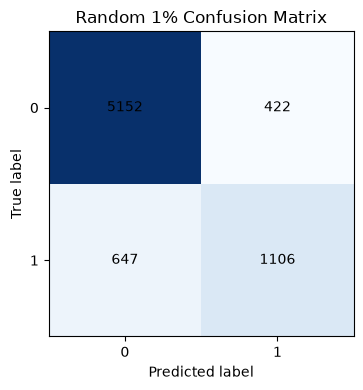

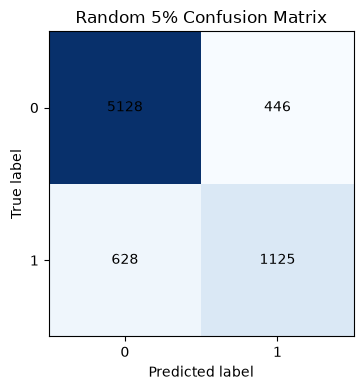

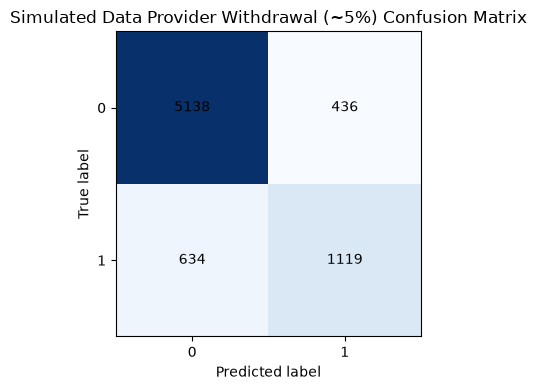

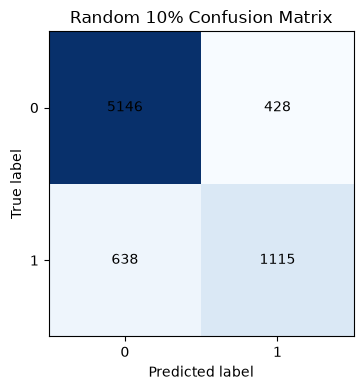

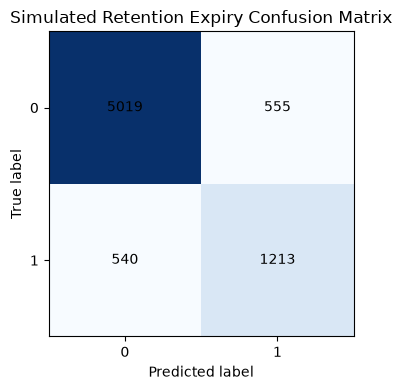

In [71]:
metrics_rows = []
classification_report_rows = []
confusion_matrix_rows = []
confusion_matrix_figures = {}
for scenario in scenario_names:
    metrics, report_rows, matrix_row, fig = evaluate_scenario_predictions(scenario, gradient_ascent_predictions)
    metrics_rows.append(metrics)
    classification_report_rows.extend(report_rows)
    confusion_matrix_rows.append(matrix_row)
    confusion_matrix_figures[scenario] = fig

gradient_ascent_metrics = pd.DataFrame(metrics_rows)
classification_reports_df = pd.DataFrame(classification_report_rows)
confusion_matrices_df = pd.DataFrame(confusion_matrix_rows)
display(gradient_ascent_metrics)
display(classification_reports_df)
confusion_matrices_df

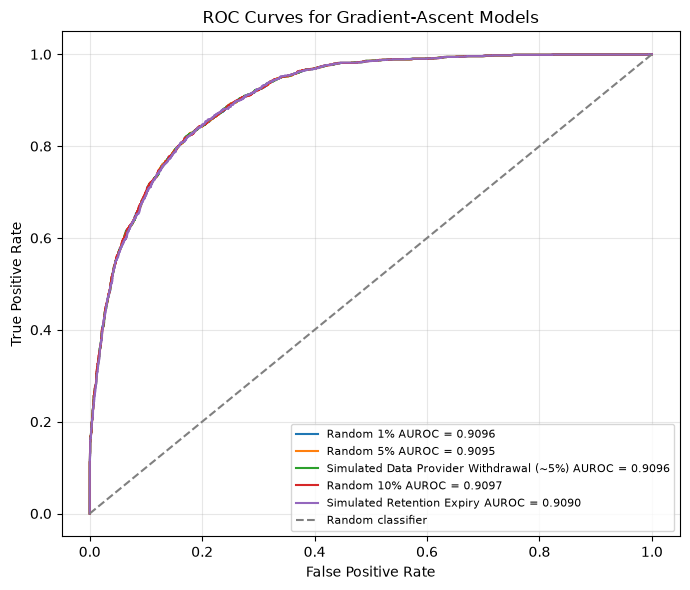

In [72]:
roc_curve_rows = []
roc_fig, roc_ax = plt.subplots(figsize=(7, 6))
for scenario in scenario_names:
    scenario_predictions = gradient_ascent_predictions[gradient_ascent_predictions["scenario"] == scenario]
    fpr, tpr, thresholds = roc_curve(scenario_predictions["y_true"], scenario_predictions["y_prob"])
    auc_value = roc_auc_score(scenario_predictions["y_true"], scenario_predictions["y_prob"])
    roc_ax.plot(fpr, tpr, label=f"{scenario_display_names[scenario]} AUROC = {auc_value:.4f}")
    for fpr_value, tpr_value, threshold in zip(fpr, tpr, thresholds):
        roc_curve_rows.append({"scenario": scenario, "false_positive_rate": fpr_value, "true_positive_rate": tpr_value, "threshold": threshold})
roc_ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
roc_ax.set_xlabel("False Positive Rate")
roc_ax.set_ylabel("True Positive Rate")
roc_ax.set_title("ROC Curves for Gradient-Ascent Models")
roc_ax.legend(fontsize=8)
roc_ax.grid(alpha=0.3)
roc_fig.tight_layout()
roc_curves_df = pd.DataFrame(roc_curve_rows)
plt.show()

## 6.2 Utility Comparison with Full Retraining

Gradient-ascent utility is compared with the matching fully retrained reference using accuracy, precision, recall, F1 and AUROC differences.

In [73]:
utility_comparison = gradient_ascent_metrics.merge(
    retrained_metrics_for_comparison,
    on="scenario",
    suffixes=("_gradient_ascent", "_retrained"),
)
for metric in ["accuracy", "precision", "recall", "f1_score", "roc_auc"]:
    utility_comparison[f"{metric}_difference"] = utility_comparison[f"{metric}_gradient_ascent"] - utility_comparison[f"{metric}_retrained"]
utility_comparison

,scenario,display_name_gradient_ascent,accuracy_gradient_ascent,precision_gradient_ascent,recall_gradient_ascent,f1_score_gradient_ascent,balanced_accuracy,roc_auc_gradient_ascent,display_name_retrained,forget_count,...,roc_auc_difference_from_baseline,actual_epochs_run,runtime_seconds,precision_retrained,recall_retrained,accuracy_difference,precision_difference,recall_difference,f1_score_difference,roc_auc_difference
0,s1_random_1_percent,Random 1%,0.854101,0.723822,0.630918,0.674185,0.777605,0.909594,Random 1%,342,...,0.000199,12,6.158163,0.742001,0.621791,-0.003685,-0.018179,0.009127,-0.002414,-0.000262
1,s2_random_5_percent,Random 5%,0.853419,0.716104,0.641757,0.676895,0.780871,0.909510,Random 5%,1709,...,-0.000297,15,6.309743,0.734762,0.625784,-0.003003,-0.018658,0.015973,0.000986,0.000150
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),0.853965,0.719614,0.638334,0.676542,0.780057,0.909554,Simulated Data Provider Withdrawal (~5%),1698,...,0.000486,11,4.582676,0.745084,0.605248,-0.002047,-0.025470,0.033086,0.008616,-0.000589
3,s4_random_10_percent,Random 10%,0.854511,0.722618,0.636052,0.676578,0.779634,0.909695,Random 10%,3419,...,-0.000219,13,5.082448,0.732262,0.624073,-0.000955,-0.009644,0.011979,0.002725,0.000257
4,s5_retention_expiry,Simulated Retention Expiry,0.850553,0.686086,0.691957,0.689009,0.796194,0.909049,Simulated Retention Expiry,5585,...,-0.001220,14,5.083569,0.747525,0.602966,-0.005732,-0.061439,0.088990,0.021500,0.000613


## 6.3 Utility Evaluation Summary

The utility summary compares selected gradient-ascent models with both the original baseline and the fully retrained reference.

In [74]:
baseline_metric_values = baseline_metrics.set_index("metric")["value"]
baseline_comparison = gradient_ascent_metrics.copy()
baseline_comparison["baseline_accuracy"] = baseline_metric_values.loc["accuracy"]
baseline_comparison["baseline_f1_score"] = baseline_metric_values.loc["f1_score"]
baseline_comparison["baseline_roc_auc"] = baseline_metric_values.loc["roc_auc"]
baseline_comparison["accuracy_vs_baseline"] = baseline_comparison["accuracy"] - baseline_comparison["baseline_accuracy"]
baseline_comparison["f1_score_vs_baseline"] = baseline_comparison["f1_score"] - baseline_comparison["baseline_f1_score"]
baseline_comparison["roc_auc_vs_baseline"] = baseline_comparison["roc_auc"] - baseline_comparison["baseline_roc_auc"]
baseline_comparison

,scenario,display_name,accuracy,precision,recall,f1_score,balanced_accuracy,roc_auc,baseline_accuracy,baseline_f1_score,baseline_roc_auc,accuracy_vs_baseline,f1_score_vs_baseline,roc_auc_vs_baseline
0,s1_random_1_percent,Random 1%,0.854101,0.723822,0.630918,0.674185,0.777605,0.909594,0.856012,0.675085,0.909657,-0.001911,-0.000900,-0.000063
1,s2_random_5_percent,Random 5%,0.853419,0.716104,0.641757,0.676895,0.780871,0.909510,0.856012,0.675085,0.909657,-0.002593,0.001811,-0.000147
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),0.853965,0.719614,0.638334,0.676542,0.780057,0.909554,0.856012,0.675085,0.909657,-0.002047,0.001457,-0.000103
3,s4_random_10_percent,Random 10%,0.854511,0.722618,0.636052,0.676578,0.779634,0.909695,0.856012,0.675085,0.909657,-0.001501,0.001493,0.000038
4,s5_retention_expiry,Simulated Retention Expiry,0.850553,0.686086,0.691957,0.689009,0.796194,0.909049,0.856012,0.675085,0.909657,-0.005459,0.013924,-0.000607


The retain-set utility table checks whether the selected gradient-ascent models preserve behaviour on records that should remain learned. It reports the original baseline, the full-retraining reference and the selected gradient-ascent model for each deletion scenario.

In [75]:
retain_performance_rows = []

for scenario in scenario_names:
    X_retain = X_train_processed.loc[retain_indices[scenario]]
    y_retain_scenario = y_train.loc[retain_indices[scenario]]
    retain_models = {
        "baseline": baseline_model,
        "fully_retrained": retrained_models[scenario],
        "gradient_ascent": gradient_ascent_results[scenario]["model"],
    }

    for model_name, model in retain_models.items():
        retain_metrics = evaluate_subset(model, X_retain, y_retain_scenario)
        retain_performance_rows.append(
            {
                "scenario": scenario,
                "display_name": scenario_display_names[scenario],
                "model": model_name,
                "retain_count": len(X_retain),
                **retain_metrics,
            }
        )

retain_performance = pd.DataFrame(retain_performance_rows)
retain_performance

,scenario,display_name,model,retain_count,accuracy,precision,recall,f1_score,balanced_accuracy,roc_auc,loss,probabilities,predictions
0,s1_random_1_percent,Random 1%,baseline,33847,0.859988,0.736177,0.647255,0.688858,0.787111,0.918766,0.298870,"[0.0002986128, 0.4716174, 0.0017284638, 0.0012...","[0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, ..."
1,s1_random_1_percent,Random 1%,fully_retrained,33847,0.860047,0.742302,0.636521,0.685354,0.783473,0.918189,0.299450,"[0.0004033158, 0.4043612, 0.0014973639, 0.0012...","[0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, ..."
2,s1_random_1_percent,Random 1%,gradient_ascent,33847,0.859663,0.731284,0.654411,0.690715,0.789349,0.918721,0.299168,"[0.00031150284, 0.4781163, 0.001774207, 0.0013...","[0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, ..."
3,s2_random_5_percent,Random 5%,baseline,32480,0.859575,0.734899,0.647346,0.688350,0.786890,0.918679,0.299159,"[0.0002986128, 0.4716174, 0.0017284638, 0.0012...","[0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, ..."
4,s2_random_5_percent,Random 5%,fully_retrained,32480,0.860252,0.737196,0.647475,0.689429,0.787380,0.919523,0.298126,"[0.00028284432, 0.5197735, 0.0017414809, 0.001...","[0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, ..."
5,s2_random_5_percent,Random 5%,gradient_ascent,32480,0.858744,0.722571,0.666110,0.693192,0.792770,0.918595,0.300277,"[0.00035765974, 0.49200588, 0.0020538568, 0.00...","[0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, ..."
6,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),baseline,32491,0.860207,0.736034,0.647748,0.689074,0.787366,0.918659,0.298818,"[0.0002986128, 0.4716174, 0.0017284638, 0.0012...","[0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, ..."
7,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),fully_retrained,32491,0.859592,0.748067,0.622523,0.679545,0.778314,0.917648,0.300133,"[0.00036437306, 0.44236928, 0.0013066839, 0.00...","[0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, ..."
8,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),gradient_ascent,32491,0.859161,0.725629,0.661004,0.691810,0.791224,0.918598,0.299832,"[0.00035690752, 0.49469998, 0.002093931, 0.001...","[0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, ..."
9,s4_random_10_percent,Random 10%,baseline,30770,0.859344,0.733906,0.648780,0.688723,0.787280,0.918640,0.299109,"[0.0017284638, 0.0012911457, 0.770099, 0.00127...","[0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, ..."


# 7. Forgetfulness Evaluation

Forgetfulness evaluation combines entropy-based uncertainty evidence with membership-inference diagnostics. Entropy and MIA are related but distinct empirical measurements.

## 7.1 Entropy-Based Forgetfulness Evaluation

Entropy is evaluated on the complete forget set for the baseline, every gradient-ascent checkpoint and the fully retrained reference. Similarity to full retraining is the target; entropy does not simply need to increase.

In [76]:
# Entropy is presented separately from probability/loss behaviour.
entropy_epoch_sweep_table = gradient_ascent_epoch_sweep_results[
    [
        "scenario", "display_name", "method", "epoch", "is_epoch_zero_control", "is_selected_checkpoint",
        "forget_entropy_mae_to_retraining", "baseline_entropy_mae_to_retraining", "relative_entropy_improvement",
        "forget_entropy_wasserstein_to_retraining", "entropy_records_moved_closer_percentage",
        "entropy_records_unchanged_percentage", "entropy_records_moved_further_percentage",
    ]
].copy()

entropy_summary_rows = []
for scenario in scenario_names:
    scenario_rows = gradient_ascent_epoch_sweep_results[gradient_ascent_epoch_sweep_results["scenario"] == scenario]
    fine_tuned_rows = scenario_rows[scenario_rows["epoch"] > 0]
    best_entropy_row = fine_tuned_rows.loc[fine_tuned_rows["forget_entropy_mae_to_retraining"].idxmin()]
    selected_row = scenario_rows[scenario_rows["is_selected_checkpoint"]].iloc[0]
    entropy_summary_rows.append(
        {
            "scenario": scenario,
            "display_name": scenario_display_names[scenario],
            "best_positive_gradient_ascent_epoch": int(best_entropy_row["epoch"]),
            "best_positive_relative_entropy_improvement": best_entropy_row["relative_entropy_improvement"],
            "selected_epoch": int(selected_row["epoch"]),
            "selected_relative_entropy_improvement": selected_row["relative_entropy_improvement"],
            "selected_entropy_mae_to_retraining": selected_row["forget_entropy_mae_to_retraining"],
            "selected_entropy_wasserstein_to_retraining": selected_row["forget_entropy_wasserstein_to_retraining"],
        }
    )
entropy_summary = pd.DataFrame(entropy_summary_rows)
display(entropy_epoch_sweep_table)
entropy_summary

,scenario,display_name,method,epoch,is_epoch_zero_control,is_selected_checkpoint,forget_entropy_mae_to_retraining,baseline_entropy_mae_to_retraining,relative_entropy_improvement,forget_entropy_wasserstein_to_retraining,entropy_records_moved_closer_percentage,entropy_records_unchanged_percentage,entropy_records_moved_further_percentage
0,s1_random_1_percent,Random 1%,NegGrad,0,True,False,0.017910,0.017910,0.000000,0.008703,0.000000,100.000000,0.000000
1,s1_random_1_percent,Random 1%,NegGrad,1,False,False,0.018355,0.017910,-0.024811,0.008895,39.181287,3.801170,57.017544
2,s1_random_1_percent,Random 1%,NegGrad,2,False,False,0.018969,0.017910,-0.059085,0.009186,39.473684,2.046784,58.479532
3,s1_random_1_percent,Random 1%,NegGrad,3,False,True,0.019766,0.017910,-0.103602,0.009501,38.596491,0.584795,60.818713
4,s2_random_5_percent,Random 5%,NegGrad,0,True,False,0.021005,0.021005,0.000000,0.006780,0.000000,100.000000,0.000000
5,s2_random_5_percent,Random 5%,NegGrad,1,False,False,0.020340,0.021005,0.031694,0.005208,53.013458,0.994734,45.991808
6,s2_random_5_percent,Random 5%,NegGrad,2,False,False,0.020098,0.021005,0.043192,0.004143,48.800468,0.643651,50.555881
7,s2_random_5_percent,Random 5%,NegGrad,3,False,True,0.021421,0.021005,-0.019773,0.004506,42.715038,0.702165,56.582797
8,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),NegGrad,0,True,False,0.023212,0.023212,0.000000,0.009781,0.000000,100.000000,0.000000
9,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),NegGrad,1,False,False,0.027187,0.023212,-0.171279,0.012360,18.138987,0.824499,81.036514


,scenario,display_name,best_positive_gradient_ascent_epoch,best_positive_relative_entropy_improvement,selected_epoch,selected_relative_entropy_improvement,selected_entropy_mae_to_retraining,selected_entropy_wasserstein_to_retraining
0,s1_random_1_percent,Random 1%,1,-0.024811,3,-0.103602,0.019766,0.009501
1,s2_random_5_percent,Random 5%,2,0.043192,3,-0.019773,0.021421,0.004506
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),1,-0.171279,3,-0.478683,0.034323,0.017945
3,s4_random_10_percent,Random 10%,1,0.005301,3,-0.109104,0.027114,0.017120
4,s5_retention_expiry,Simulated Retention Expiry,1,-0.052622,3,-0.733967,0.088437,0.039623


## 7.2 Membership Inference Diagnostics

A representative S1 loss-distribution plot is shown before the scenario-level MIA tables. The attack protocol itself matches Notebook 3.

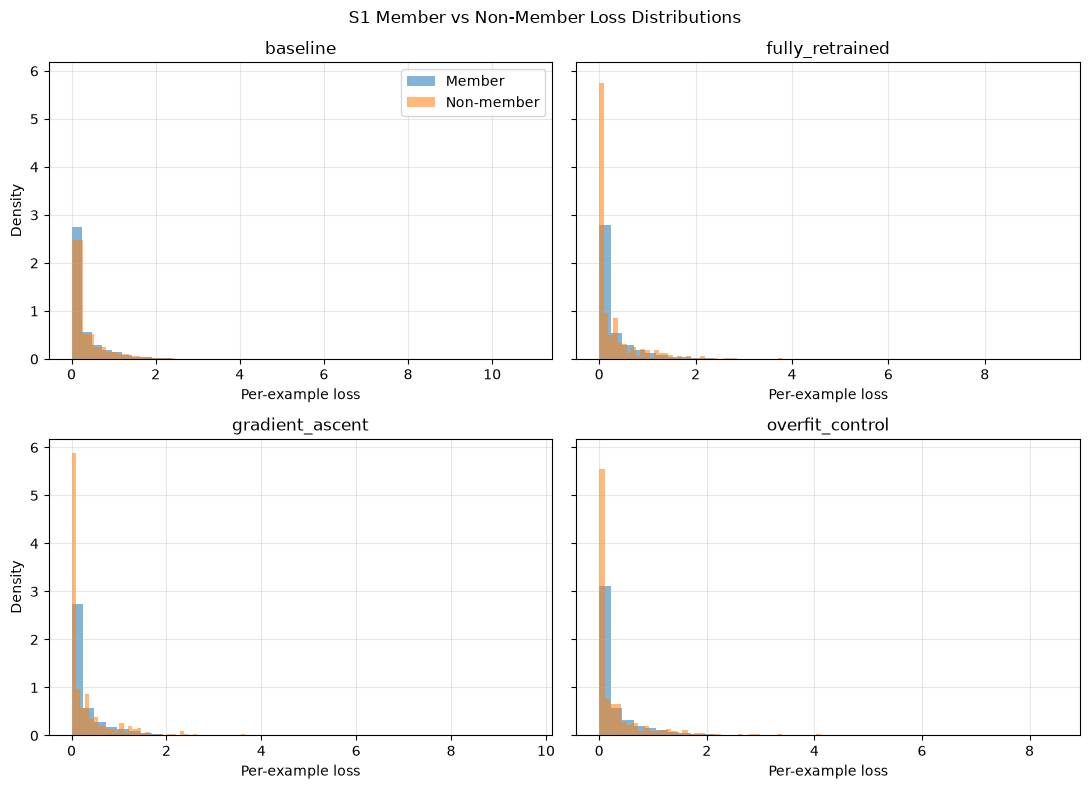

,scenario,display_name,model,attack_type,member_set,non_member_set,attack_auc,attack_auc_ci_low,attack_auc_ci_high,tpr_at_fpr_0.001,tpr_at_fpr_0.01,tpr_at_fpr_0.05,permutation_p_value,mean_member_score,mean_non_member_score,attack_auc_bootstrap_mean,threshold_balanced_attack_accuracy,attack_threshold,member_count,non_member_count
0,s1_random_1_percent,Random 1%,baseline,confidence,train,test,0.504910,0.498449,0.511349,0.0,0.008541,0.048905,0.115,0.805364,0.800279,0.504862,0.502382,0.993145,34189,7327
1,s1_random_1_percent,Random 1%,baseline,loss,train,test,0.504910,0.497418,0.512798,0.0,0.008044,0.048875,0.100,-0.298928,-0.312553,0.504906,0.502382,-0.006879,34189,7327
2,s1_random_1_percent,Random 1%,fully_retrained,confidence,retain,forget,0.486451,0.457558,0.525055,0.0,0.009868,0.040594,0.830,0.806945,0.805059,0.489126,0.485982,0.993517,33847,342
3,s1_random_1_percent,Random 1%,fully_retrained,loss,retain,forget,0.486451,0.447571,0.514243,0.0,0.009838,0.040535,0.865,-0.299450,-0.314262,0.485608,0.485982,-0.006504,33847,342
4,s1_random_1_percent,Random 1%,gradient_ascent,confidence,retain,forget,0.485333,0.456572,0.516649,0.0,0.012261,0.043963,0.730,0.804955,0.805720,0.484161,0.487459,0.993044,33847,342


In [77]:
# MIA results are first built per scenario, then split into reader-facing summaries.
mia_result_frames = []
# MIA is run on each scenario using the same model configuration builder.
for scenario in scenario_names:
    mia_result_frames.append(evaluate_membership_attack_scenario(scenario))
mia_results_v2 = pd.concat(mia_result_frames, ignore_index=True)
mia_results = mia_results_v2.copy()

representative_scenario = "s1_random_1_percent"
representative_models = ["baseline", "fully_retrained", "gradient_ascent", "overfit_control"]
loss_distribution_fig, loss_distribution_axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
loss_distribution_axes = loss_distribution_axes.ravel()
for ax, model_name in zip(loss_distribution_axes, representative_models):
    score_entry = mia_score_cache[(representative_scenario, model_name)]
    ax.hist(score_entry["member"]["raw_loss"], bins=40, alpha=0.55, density=True, label="Member")
    ax.hist(score_entry["non_member"]["raw_loss"], bins=40, alpha=0.55, density=True, label="Non-member")
    ax.set_title(model_name)
    ax.set_xlabel("Per-example loss")
    ax.grid(alpha=0.3)
loss_distribution_axes[0].set_ylabel("Density")
loss_distribution_axes[2].set_ylabel("Density")
loss_distribution_axes[0].legend()
loss_distribution_fig.suptitle("S1 Member vs Non-Member Loss Distributions")
loss_distribution_fig.tight_layout()
plt.show()
mia_results.head()

## 7.3 Confidence-Based Membership Inference

Confidence-based attacks use the probability assigned to the true class as the membership signal.

In [78]:
mia_confidence_results = mia_results_v2[mia_results_v2["attack_type"].str.contains("confidence", case=False, na=False)].reset_index(drop=True)
mia_confidence_results

,scenario,display_name,model,attack_type,member_set,non_member_set,attack_auc,attack_auc_ci_low,attack_auc_ci_high,tpr_at_fpr_0.001,tpr_at_fpr_0.01,tpr_at_fpr_0.05,permutation_p_value,mean_member_score,mean_non_member_score,attack_auc_bootstrap_mean,threshold_balanced_attack_accuracy,attack_threshold,member_count,non_member_count
0,s1_random_1_percent,Random 1%,baseline,confidence,train,test,0.504910,0.498449,0.511349,0.0,0.008541,0.048905,0.115,0.805364,0.800279,0.504862,0.502382,0.993145,34189,7327
1,s1_random_1_percent,Random 1%,fully_retrained,confidence,retain,forget,0.486451,0.457558,0.525055,0.0,0.009868,0.040594,0.830,0.806945,0.805059,0.489126,0.485982,0.993517,33847,342
2,s1_random_1_percent,Random 1%,gradient_ascent,confidence,retain,forget,0.485333,0.456572,0.516649,0.0,0.012261,0.043963,0.730,0.804955,0.805720,0.484161,0.487459,0.993044,33847,342
3,s1_random_1_percent,Random 1%,overfit_control,confidence,retain,forget,0.490914,0.459571,0.520010,0.0,0.011788,0.038999,0.740,0.815341,0.809640,0.490586,0.488935,0.994669,33847,342
4,s2_random_5_percent,Random 5%,baseline,confidence,train,test,0.504910,0.498449,0.511349,0.0,0.008541,0.048905,0.115,0.805364,0.800279,0.504862,0.502382,0.993145,34189,7327
5,s2_random_5_percent,Random 5%,fully_retrained,confidence,retain,forget,0.504221,0.491847,0.517807,0.0,0.009760,0.054310,0.300,0.804412,0.800965,0.504786,0.502244,0.993226,32480,1709
6,s2_random_5_percent,Random 5%,gradient_ascent,confidence,retain,forget,0.502287,0.488931,0.516614,0.0,0.008621,0.052309,0.380,0.803005,0.802300,0.501856,0.501628,0.992352,32480,1709
7,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),baseline,confidence,train,test,0.504910,0.498449,0.511349,0.0,0.008541,0.048905,0.115,0.805364,0.800279,0.504862,0.502382,0.993145,34189,7327
8,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),fully_retrained,confidence,retain,forget,0.505529,0.492285,0.521717,0.0,0.009510,0.046505,0.180,0.807199,0.802418,0.505319,0.506364,0.993931,32491,1698
9,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),gradient_ascent,confidence,retain,forget,0.504653,0.491782,0.520143,0.0,0.010403,0.046044,0.265,0.803379,0.800412,0.505108,0.506054,0.992198,32491,1698


## 7.4 Loss-Based Membership Inference

Loss-based attacks use negative per-record loss as the membership signal. This is the primary MIA diagnostic in this notebook.

In [79]:
mia_loss_results = mia_results_v2[mia_results_v2["attack_type"].str.contains("loss", case=False, na=False)].reset_index(drop=True)
mia_loss_results

,scenario,display_name,model,attack_type,member_set,non_member_set,attack_auc,attack_auc_ci_low,attack_auc_ci_high,tpr_at_fpr_0.001,tpr_at_fpr_0.01,tpr_at_fpr_0.05,permutation_p_value,mean_member_score,mean_non_member_score,attack_auc_bootstrap_mean,threshold_balanced_attack_accuracy,attack_threshold,member_count,non_member_count
0,s1_random_1_percent,Random 1%,baseline,loss,train,test,0.504910,0.497418,0.512798,0.0,0.008044,0.048875,0.100,-0.298928,-0.312553,0.504906,0.502382,-0.006879,34189,7327
1,s1_random_1_percent,Random 1%,fully_retrained,loss,retain,forget,0.486451,0.447571,0.514243,0.0,0.009838,0.040535,0.865,-0.299450,-0.314262,0.485608,0.485982,-0.006504,33847,342
2,s1_random_1_percent,Random 1%,gradient_ascent,loss,retain,forget,0.485332,0.450133,0.512984,0.0,0.011995,0.043874,0.835,-0.299168,-0.306441,0.484321,0.487459,-0.006980,33847,342
3,s1_random_1_percent,Random 1%,overfit_control,loss,retain,forget,0.490916,0.457151,0.521983,0.0,0.011788,0.038910,0.775,-0.286290,-0.310622,0.492427,0.488935,-0.005345,33847,342
4,s2_random_5_percent,Random 5%,baseline,loss,train,test,0.504910,0.497418,0.512798,0.0,0.008044,0.048875,0.100,-0.298928,-0.312553,0.504906,0.502382,-0.006879,34189,7327
5,s2_random_5_percent,Random 5%,fully_retrained,loss,retain,forget,0.504221,0.491255,0.517253,0.0,0.009606,0.054156,0.250,-0.298126,-0.302795,0.503979,0.502244,-0.006796,32480,1709
6,s2_random_5_percent,Random 5%,gradient_ascent,loss,retain,forget,0.502287,0.488756,0.517226,0.0,0.008621,0.052248,0.345,-0.300277,-0.297151,0.502447,0.501628,-0.007677,32480,1709
7,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),baseline,loss,train,test,0.504910,0.497418,0.512798,0.0,0.008044,0.048875,0.100,-0.298928,-0.312553,0.504906,0.502382,-0.006879,34189,7327
8,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),fully_retrained,loss,retain,forget,0.505528,0.489360,0.519246,0.0,0.009356,0.046505,0.195,-0.300133,-0.309671,0.504536,0.506364,-0.006088,32491,1698
9,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),gradient_ascent,loss,retain,forget,0.504653,0.491035,0.518126,0.0,0.010280,0.046044,0.220,-0.299832,-0.303271,0.504995,0.506054,-0.007832,32491,1698


## 7.5 Low False-Positive-Rate Metrics

Low-FPR metrics report attack sensitivity at stricter operating points.

In [80]:
mia_low_fpr_summary = mia_results_v2[
    ["scenario", "display_name", "model", "attack_type", "tpr_at_fpr_0.001", "tpr_at_fpr_0.01", "tpr_at_fpr_0.05"]
].copy()
mia_low_fpr_summary

,scenario,display_name,model,attack_type,tpr_at_fpr_0.001,tpr_at_fpr_0.01,tpr_at_fpr_0.05
0,s1_random_1_percent,Random 1%,baseline,confidence,0.0,0.008541,0.048905
1,s1_random_1_percent,Random 1%,baseline,loss,0.0,0.008044,0.048875
2,s1_random_1_percent,Random 1%,fully_retrained,confidence,0.0,0.009868,0.040594
3,s1_random_1_percent,Random 1%,fully_retrained,loss,0.0,0.009838,0.040535
4,s1_random_1_percent,Random 1%,gradient_ascent,confidence,0.0,0.012261,0.043963
5,s1_random_1_percent,Random 1%,gradient_ascent,loss,0.0,0.011995,0.043874
6,s1_random_1_percent,Random 1%,overfit_control,confidence,0.0,0.011788,0.038999
7,s1_random_1_percent,Random 1%,overfit_control,loss,0.0,0.011788,0.038910
8,s2_random_5_percent,Random 5%,baseline,confidence,0.0,0.008541,0.048905
9,s2_random_5_percent,Random 5%,baseline,loss,0.0,0.008044,0.048875


## 7.6 Statistical Validation

Bootstrap confidence intervals and permutation p-values are reported for each MIA result.

In [81]:
# Statistical validation keeps p-values and confidence intervals visible for interpretation.
mia_statistical_validation = mia_results_v2[
    ["scenario", "display_name", "model", "attack_type", "attack_auc", "attack_auc_ci_low", "attack_auc_ci_high", "permutation_p_value", "attack_auc_bootstrap_mean"]
].copy()
mia_statistical_validation

,scenario,display_name,model,attack_type,attack_auc,attack_auc_ci_low,attack_auc_ci_high,permutation_p_value,attack_auc_bootstrap_mean
0,s1_random_1_percent,Random 1%,baseline,confidence,0.504910,0.498449,0.511349,0.115,0.504862
1,s1_random_1_percent,Random 1%,baseline,loss,0.504910,0.497418,0.512798,0.100,0.504906
2,s1_random_1_percent,Random 1%,fully_retrained,confidence,0.486451,0.457558,0.525055,0.830,0.489126
3,s1_random_1_percent,Random 1%,fully_retrained,loss,0.486451,0.447571,0.514243,0.865,0.485608
4,s1_random_1_percent,Random 1%,gradient_ascent,confidence,0.485333,0.456572,0.516649,0.730,0.484161
5,s1_random_1_percent,Random 1%,gradient_ascent,loss,0.485332,0.450133,0.512984,0.835,0.484321
6,s1_random_1_percent,Random 1%,overfit_control,confidence,0.490914,0.459571,0.520010,0.740,0.490586
7,s1_random_1_percent,Random 1%,overfit_control,loss,0.490916,0.457151,0.521983,0.775,0.492427
8,s2_random_5_percent,Random 5%,baseline,confidence,0.504910,0.498449,0.511349,0.115,0.504862
9,s2_random_5_percent,Random 5%,baseline,loss,0.504910,0.497418,0.512798,0.100,0.504906


## 7.7 Positive-Control Assessment

If the positive control is ineffective, the MIA results are marked inconclusive and are not interpreted as evidence of forgetting or privacy.

In [82]:
def get_loss_positive_control_summary(mia_results_table):
    rows = mia_results_table[
        (mia_results_table["scenario"] == "s1_random_1_percent")
        & (mia_results_table["model"] == "overfit_control")
        & (mia_results_table["attack_type"] == "loss")
    ]
    if rows.empty:
        return np.nan, False
    row = rows.iloc[0]
    valid = row["attack_auc"] > 0.55 and row["attack_auc_ci_low"] > 0.5
    return float(row["attack_auc"]), bool(valid)

# MIA is marked inconclusive unless the overfit control is clearly detectable.
positive_control_auc, positive_control_valid = get_loss_positive_control_summary(mia_results_v2)
print(f"Loss-based MIA positive-control AUROC: {positive_control_auc:.4f} | valid={positive_control_valid}")

Loss-based MIA positive-control AUROC: 0.4909 | valid=False


## 7.8 Forgetfulness Evaluation Summary

The shared evaluator combines utility, forget-set fidelity and membership-inference diagnostics. Entropy, MIA and behavioural similarity remain separate lines of empirical evidence.

In [83]:
# Optimiser steps come from the selected gradient-ascent run metadata.
def estimate_optimizer_steps(result):
    return int(result["optimizer_steps"])

gradient_ascent_evaluation_rows = []
gradient_ascent_forget_detail_frames = []
for scenario in scenario_names:
    # The shared evaluator aligns utility, forget-set fidelity and MIA columns across methods.
    evaluation_row, detail_tables = evaluate_unlearning_method(
        original_model=baseline_model,
        unlearned_model=gradient_ascent_results[scenario]["model"],
        retrained_model=retrained_models[scenario],
        X_retain=X_train_processed.loc[retain_indices[scenario]],
        y_retain=y_train.loc[retain_indices[scenario]],
        X_forget=X_train_processed.loc[forget_indices[scenario]],
        y_forget=y_train.loc[forget_indices[scenario]],
        X_test=X_test_processed,
        y_test=y_test,
        scenario_name=scenario,
        method_name="gradient_ascent",
        runtime=gradient_ascent_results[scenario]["runtime_seconds"],
        optimizer_steps=estimate_optimizer_steps(gradient_ascent_results[scenario]),
        random_seed=RANDOM_SEED,
        mia_positive_control_auc=positive_control_auc,
        mia_positive_control_valid=positive_control_valid,
        return_details=True,
    )
    gradient_ascent_evaluation_rows.append(evaluation_row)
    # Detail tables are kept separate so record-level fidelity can be audited later.
    gradient_ascent_forget_detail_frames.extend(
        [
            detail_tables["forget_unlearned"],
            detail_tables["forget_retrained"],
            detail_tables["forget_original"],
        ]
    )

gradient_ascent_unlearning_evaluation = pd.concat(
    gradient_ascent_evaluation_rows,
    ignore_index=True,
)
gradient_ascent_forget_details = pd.concat(
    gradient_ascent_forget_detail_frames,
    ignore_index=True,
)

gradient_ascent_forget_set_fidelity_table = gradient_ascent_unlearning_evaluation[
    [
        "scenario", "method", "forget_size", "forget_percentage", "forget_ks_statistic", "forget_ks_pvalue",
        "forget_wasserstein", "forget_mean_loss_gap", "forget_probability_mad", "forget_agreement_retrain",
        "original_retrain_forget_ks", "original_retrain_forget_wasserstein", "mia_auroc", "mia_attack_advantage",
        "mia_auc_ci_low", "mia_auc_ci_high", "mia_positive_control_auc", "mia_positive_control_valid", "mia_interpretation",
    ]
]
gradient_ascent_forget_set_fidelity_table

,scenario,method,forget_size,forget_percentage,forget_ks_statistic,forget_ks_pvalue,forget_wasserstein,forget_mean_loss_gap,forget_probability_mad,forget_agreement_retrain,original_retrain_forget_ks,original_retrain_forget_wasserstein,mia_auroc,mia_attack_advantage,mia_auc_ci_low,mia_auc_ci_high,mia_positive_control_auc,mia_positive_control_valid,mia_interpretation
0,s1_random_1_percent,gradient_ascent,342,0.010003,0.032164,9.945515e-01,0.014730,0.007821,0.011861,0.979532,0.035088,0.015112,0.493203,0.013594,0.454491,0.533950,0.490916,False,inconclusive
1,s2_random_5_percent,gradient_ascent,1709,0.049987,0.015799,9.833614e-01,0.007847,0.005644,0.013803,0.980105,0.015214,0.008622,0.505754,0.011509,0.488825,0.524433,0.490916,False,inconclusive
2,s3_simulated_data_provider_withdrawal,gradient_ascent,1698,0.049665,0.035925,2.232484e-01,0.016360,0.006400,0.018624,0.982332,0.020612,0.013181,0.496747,0.006506,0.477748,0.515582,0.490916,False,inconclusive
3,s4_random_10_percent,gradient_ascent,3419,0.100003,0.024861,2.412999e-01,0.019208,0.008638,0.015524,0.983913,0.011992,0.014658,0.500933,0.001866,0.487330,0.512847,0.490916,False,inconclusive
4,s5_retention_expiry,gradient_ascent,5585,0.163357,0.053536,2.220387e-07,0.039093,0.016360,0.060148,0.913697,0.035452,0.038243,0.600195,0.200389,0.590255,0.610460,0.490916,False,inconclusive


# 8. Computational Evaluation

Computational evaluation compares gradient-ascent runtime with full retraining. The comparison uses method-specific configurations and is not an equal-compute comparison.

## 8.1 Gradient-Ascent Runtime

This table reports configured epochs, actual epochs, selected epochs, optimiser steps and full forget-set coverage for each selected model.

In [84]:
if "selected_method" not in selected_configurations.columns:
    selected_configurations["selected_method"] = selected_configurations["scenario"].map(
        {scenario: result["method"] for scenario, result in gradient_ascent_results.items()}
    )

gradient_ascent_runtime_summary = selected_configurations[
    [
        "scenario", "display_name", "selected_method", "configured_max_epochs", "actual_epochs_completed",
        "selected_epoch", "optimizer_steps", "runtime_seconds", "selection_valid", "early_stopping_reason",
    ]
].copy()
gradient_ascent_runtime_summary["complete_forget_set_coverage"] = True
gradient_ascent_runtime_summary

,scenario,display_name,selected_method,configured_max_epochs,actual_epochs_completed,selected_epoch,optimizer_steps,runtime_seconds,selection_valid,early_stopping_reason,complete_forget_set_coverage
0,s1_random_1_percent,Random 1%,NegGrad,10,3,3,6,0.025172,True,no_validation_acceptable_forget_loss_improvement,True
1,s2_random_5_percent,Random 5%,NegGrad,10,3,3,21,0.083944,True,no_validation_acceptable_forget_loss_improvement,True
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),NegGrad,10,3,3,21,0.083554,True,no_validation_acceptable_forget_loss_improvement,True
3,s4_random_10_percent,Random 10%,NegGrad,10,3,3,42,0.153832,True,no_validation_acceptable_forget_loss_improvement,True
4,s5_retention_expiry,Simulated Retention Expiry,NegGrad,10,3,3,66,0.234196,True,no_validation_acceptable_forget_loss_improvement,True


## 8.2 Full-Retraining Runtime

Full-retraining runtime is loaded from Notebook 2 and used as the empirical computational reference.

In [85]:
full_retraining_runtime_display = retraining_runtime_summary.copy()
full_retraining_runtime_display

,display_name,scenario,retain_count,configured_max_epochs,actual_epochs_run,best_epoch,best_val_loss,early_stopping_triggered,runtime_seconds,runtime_per_epoch
0,Random 1%,s1_random_1_percent,33847,20,12,9,0.300915,True,6.158163,0.513180
1,Random 5%,s2_random_5_percent,32480,20,15,12,0.301174,True,6.309743,0.420650
2,Simulated Data Provider Withdrawal (~5%),s3_simulated_data_provider_withdrawal,32491,20,11,8,0.301764,True,4.582676,0.416607
3,Random 10%,s4_random_10_percent,30770,20,13,10,0.301386,True,5.082448,0.390958
4,Simulated Retention Expiry,s5_retention_expiry,28604,20,14,11,0.302443,True,5.083569,0.363112


## 8.3 Runtime Comparison

The runtime comparison joins gradient-ascent runtime with full-retraining runtime for each scenario.

In [86]:
runtime_comparison = gradient_ascent_runtime_summary.merge(
    retraining_runtime_summary[["scenario", "runtime_seconds"]].rename(columns={"runtime_seconds": "runtime_seconds_retrained"}),
    on="scenario",
    how="left",
    validate="one_to_one",
).rename(columns={"runtime_seconds": "runtime_seconds_gradient_ascent"})
runtime_comparison["runtime_difference_seconds"] = runtime_comparison["runtime_seconds_gradient_ascent"] - runtime_comparison["runtime_seconds_retrained"]
runtime_comparison["runtime_ratio_gradient_ascent_to_retrained"] = runtime_comparison["runtime_seconds_gradient_ascent"] / runtime_comparison["runtime_seconds_retrained"]
runtime_comparison

,scenario,display_name,selected_method,configured_max_epochs,actual_epochs_completed,selected_epoch,optimizer_steps,runtime_seconds_gradient_ascent,selection_valid,early_stopping_reason,complete_forget_set_coverage,runtime_seconds_retrained,runtime_difference_seconds,runtime_ratio_gradient_ascent_to_retrained
0,s1_random_1_percent,Random 1%,NegGrad,10,3,3,6,0.025172,True,no_validation_acceptable_forget_loss_improvement,True,6.158163,-6.132991,0.004088
1,s2_random_5_percent,Random 5%,NegGrad,10,3,3,21,0.083944,True,no_validation_acceptable_forget_loss_improvement,True,6.309743,-6.225799,0.013304
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),NegGrad,10,3,3,21,0.083554,True,no_validation_acceptable_forget_loss_improvement,True,4.582676,-4.499122,0.018233
3,s4_random_10_percent,Random 10%,NegGrad,10,3,3,42,0.153832,True,no_validation_acceptable_forget_loss_improvement,True,5.082448,-4.928615,0.030267
4,s5_retention_expiry,Simulated Retention Expiry,NegGrad,10,3,3,66,0.234196,True,no_validation_acceptable_forget_loss_improvement,True,5.083569,-4.849373,0.046069


## 8.4 Hyperparameter and Checkpoint Selection Analysis

This section displays the selected configuration table and keeps the complete hyperparameter-search table for saving.

In [87]:
display(selected_configurations)
hyperparameter_search_results.head(20)

,scenario,display_name,selected_method,learning_rate,retain_weight,configured_max_epochs,actual_epochs_completed,selected_epoch,optimizer_steps,forget_loss_change,validation_loss,validation_accuracy,validation_f1,validation_balanced_accuracy,validation_auroc,runtime_seconds,selection_valid,early_stopping_reason
0,s1_random_1_percent,Random 1%,NegGrad,0.0001,0.0,10,3,3,6,0.001783,0.301217,0.860633,0.690137,0.787965,0.916526,0.025172,True,no_validation_acceptable_forget_loss_improvement
1,s2_random_5_percent,Random 5%,NegGrad,0.0001,0.0,10,3,3,21,0.002608,0.301675,0.861179,0.694503,0.792039,0.916529,0.083944,True,no_validation_acceptable_forget_loss_improvement
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),NegGrad,0.0001,0.0,10,3,3,21,0.002242,0.301651,0.861452,0.694553,0.791827,0.916481,0.083554,True,no_validation_acceptable_forget_loss_improvement
3,s4_random_10_percent,Random 10%,NegGrad,0.0001,0.0,10,3,3,42,0.002156,0.301560,0.861179,0.692842,0.790279,0.916500,0.153832,True,no_validation_acceptable_forget_loss_improvement
4,s5_retention_expiry,Simulated Retention Expiry,NegGrad,0.0001,0.0,10,3,3,66,0.010139,0.306356,0.859951,0.706354,0.806481,0.915938,0.234196,True,no_validation_acceptable_forget_loss_improvement


,candidate_index,scenario,display_name,method,learning_rate,retain_weight,selected_epoch,actual_epochs_completed,optimizer_steps,runtime_seconds,forget_loss_change,selection_valid,validation_loss,validation_accuracy,validation_f1,validation_balanced_accuracy,validation_auroc,validation_safety_score,early_stopping_reason
0,0,s1_random_1_percent,Random 1%,NegGrad,0.00001,0.0,3,3,6,0.033093,0.000173,True,0.301052,0.861043,0.688685,0.786084,0.916571,-0.0,no_validation_acceptable_forget_loss_improvement
1,1,s1_random_1_percent,Random 1%,NegGrad,0.00005,0.0,3,3,6,0.025125,0.000898,True,0.301114,0.860770,0.688835,0.786491,0.916561,-0.0,no_validation_acceptable_forget_loss_improvement
2,2,s1_random_1_percent,Random 1%,NegGrad,0.00010,0.0,3,3,6,0.025172,0.001783,True,0.301217,0.860633,0.690137,0.787965,0.916526,-0.0,no_validation_acceptable_forget_loss_improvement
3,3,s1_random_1_percent,Random 1%,NegGrad+,0.00001,0.1,3,3,6,0.041441,0.000173,True,0.301054,0.861179,0.688896,0.786174,0.916571,-0.0,no_validation_acceptable_forget_loss_improvement
4,4,s1_random_1_percent,Random 1%,NegGrad+,0.00001,0.5,3,3,6,0.043849,0.000162,True,0.301053,0.861043,0.688494,0.785888,0.916571,-0.0,no_validation_acceptable_forget_loss_improvement
5,5,s1_random_1_percent,Random 1%,NegGrad+,0.00005,0.1,3,3,6,0.040047,0.000876,True,0.301111,0.860906,0.689045,0.786581,0.916560,-0.0,no_validation_acceptable_forget_loss_improvement
6,6,s1_random_1_percent,Random 1%,NegGrad+,0.00005,0.5,3,3,6,0.042298,0.000804,True,0.301101,0.861043,0.689255,0.786670,0.916567,-0.0,no_validation_acceptable_forget_loss_improvement
7,0,s2_random_5_percent,Random 5%,NegGrad,0.00001,0.0,3,3,21,0.094253,0.000231,True,0.301071,0.861316,0.689676,0.786850,0.916572,-0.0,no_validation_acceptable_forget_loss_improvement
8,1,s2_random_5_percent,Random 5%,NegGrad,0.00005,0.0,3,3,21,0.094905,0.001160,True,0.301246,0.860497,0.690678,0.788658,0.916560,-0.0,no_validation_acceptable_forget_loss_improvement
9,2,s2_random_5_percent,Random 5%,NegGrad,0.00010,0.0,3,3,21,0.083944,0.002608,True,0.301675,0.861179,0.694503,0.792039,0.916529,-0.0,no_validation_acceptable_forget_loss_improvement


## 8.5 Computational Evaluation Summary

The summary reports runtime ratios and whether each selected model satisfied the validation-utility constraints.

In [88]:
computational_summary = runtime_comparison[
    [
        "scenario", "display_name", "selected_method", "actual_epochs_completed", "selected_epoch",
        "optimizer_steps", "complete_forget_set_coverage", "runtime_seconds_gradient_ascent",
        "runtime_seconds_retrained", "runtime_ratio_gradient_ascent_to_retrained", "selection_valid",
    ]
].copy()
computational_summary

,scenario,display_name,selected_method,actual_epochs_completed,selected_epoch,optimizer_steps,complete_forget_set_coverage,runtime_seconds_gradient_ascent,runtime_seconds_retrained,runtime_ratio_gradient_ascent_to_retrained,selection_valid
0,s1_random_1_percent,Random 1%,NegGrad,3,3,6,True,0.025172,6.158163,0.004088,True
1,s2_random_5_percent,Random 5%,NegGrad,3,3,21,True,0.083944,6.309743,0.013304,True
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),NegGrad,3,3,21,True,0.083554,4.582676,0.018233,True
3,s4_random_10_percent,Random 10%,NegGrad,3,3,42,True,0.153832,5.082448,0.030267,True
4,s5_retention_expiry,Simulated Retention Expiry,NegGrad,3,3,66,True,0.234196,5.083569,0.046069,True


# 9. Save Evaluation Outputs

All gradient-ascent models, metrics, tables and figures are saved under the gradient-ascent results directory. Retain-set fine-tuning outputs are not overwritten.

In [89]:
saved_model_paths = []
for scenario, result in gradient_ascent_results.items():
    checkpoint = {
        "scenario": scenario,
        "display_name": scenario_display_names[scenario],
        "method": result["method"],
        "learning_rate": result["learning_rate"],
        "retain_weight": result["retain_weight"],
        "selected_epoch": result["selected_epoch"],
        "configured_max_epochs": result["configured_max_epochs"],
        "actual_epochs_completed": result["actual_epochs_completed"],
        "optimizer_steps": result["optimizer_steps"],
        "runtime_seconds": result["runtime_seconds"],
        "selection_valid": result["selection_valid"],
        "early_stopping_reason": result["early_stopping_reason"],
        "input_dim": input_dim,
        "model_state_dict": state_dict_to_cpu(result["model"]),
        "random_seed": RANDOM_SEED,
    }
    output_path = gradient_ascent_models_dir / f"{scenario}_gradient_ascent_mlp.pt"
    torch.save(checkpoint, output_path)
    reloaded = torch.load(output_path, map_location=device, weights_only=False)
    reloaded_model = load_model_from_checkpoint(reloaded)
    reloaded_model.eval()
    saved_model_paths.append(output_path)

print(f"Saved and reloaded {len(saved_model_paths)} gradient-ascent models.")

Saved and reloaded 5 gradient-ascent models.


In [90]:
legacy_gradient_ascent_outputs = [
    gradient_ascent_metrics_dir / "classification_reports.csv",
    gradient_ascent_metrics_dir / "confusion_matrices.csv",
    gradient_ascent_metrics_dir / "forget_behaviour.csv",
    gradient_ascent_metrics_dir / "forget_performance.csv",
    gradient_ascent_metrics_dir / "mia_results.csv",
    gradient_ascent_metrics_dir / "mia_results_v2.csv",
    gradient_ascent_metrics_dir / "retain_performance.csv",
    gradient_ascent_metrics_dir / "roc_curves.csv",
    gradient_ascent_metrics_dir / "runtime_summary.csv",
    gradient_ascent_tables_dir / "baseline_comparison.csv",
    gradient_ascent_tables_dir / "baseline_prediction_shift.csv",
    gradient_ascent_tables_dir / "chosen_hyperparameters.csv",
    gradient_ascent_tables_dir / "gradient_ascent_comparison.csv",
    gradient_ascent_tables_dir / "gradient_ascent_predictions.csv",
    gradient_ascent_tables_dir / "probability_similarity.csv",
]

# Legacy outputs are cleared so old-scenario rows cannot survive a regenerated run.
for legacy_path in legacy_gradient_ascent_outputs:
    legacy_path.unlink(missing_ok=True)

# Compatibility tables are regenerated from current scenario outputs only.
probability_similarity = prediction_agreement[
    ["scenario", "display_name", "mean_probability_shift_from_baseline"]
].copy()
probability_similarity["probability_similarity_with_baseline"] = (
    1.0 - probability_similarity["mean_probability_shift_from_baseline"]
)

baseline_prediction_shift = probability_similarity.rename(
    columns={
        "mean_probability_shift_from_baseline": "mean_absolute_probability_shift_from_baseline",
    }
)

gradient_ascent_comparison = gradient_ascent_forget_set_fidelity_table.copy()
forget_behaviour_summary = behavioural_interpretation_table.copy()

# Current metric outputs.
# Metrics and tables are saved separately to match the project output layout.
gradient_ascent_metrics.to_csv(gradient_ascent_metrics_dir / "gradient_ascent_metrics.csv", index=False)
selected_configurations.to_csv(gradient_ascent_metrics_dir / "selected_configurations.csv", index=False)
classification_reports_df.to_csv(gradient_ascent_metrics_dir / "classification_reports.csv", index=False)
confusion_matrices_df.to_csv(gradient_ascent_metrics_dir / "confusion_matrices.csv", index=False)
roc_curves_df.to_csv(gradient_ascent_metrics_dir / "roc_curves.csv", index=False)
forget_performance.to_csv(gradient_ascent_metrics_dir / "forget_performance.csv", index=False)
retain_performance.to_csv(gradient_ascent_metrics_dir / "retain_performance.csv", index=False)
forget_behaviour_summary.to_csv(gradient_ascent_metrics_dir / "forget_behaviour.csv", index=False)
mia_results_v2.to_csv(gradient_ascent_metrics_dir / "mia_results.csv", index=False)
mia_results_v2.to_csv(gradient_ascent_metrics_dir / "mia_results_v2.csv", index=False)
gradient_ascent_runtime_summary.to_csv(gradient_ascent_metrics_dir / "runtime_summary.csv", index=False)
gradient_ascent_unlearning_evaluation.to_csv(gradient_ascent_metrics_dir / "unlearning_evaluation.csv", index=False)

# Current detailed tables and compatibility tables.
hyperparameter_search_results.to_csv(gradient_ascent_tables_dir / "hyperparameter_search_results.csv", index=False)
selected_configurations.to_csv(gradient_ascent_tables_dir / "chosen_hyperparameters.csv", index=False)
gradient_ascent_history.to_csv(gradient_ascent_tables_dir / "unlearning_histories.csv", index=False)
gradient_ascent_epoch_sweep_results.to_csv(gradient_ascent_tables_dir / "checkpoint_epoch_sweep_results.csv", index=False)
gradient_ascent_predictions.to_csv(gradient_ascent_tables_dir / "test_predictions.csv", index=False)
gradient_ascent_predictions.to_csv(gradient_ascent_tables_dir / "gradient_ascent_predictions.csv", index=False)
forget_record_predictions.to_csv(gradient_ascent_tables_dir / "forget_record_predictions.csv", index=False)
forget_performance.to_csv(gradient_ascent_tables_dir / "forget_set_performance.csv", index=False)
retain_performance.to_csv(gradient_ascent_tables_dir / "retain_set_performance.csv", index=False)
behaviour_epoch_sweep_table.to_csv(gradient_ascent_tables_dir / "behaviour_epoch_sweep_table.csv", index=False)
prediction_agreement.to_csv(gradient_ascent_tables_dir / "prediction_agreement.csv", index=False)
probability_similarity.to_csv(gradient_ascent_tables_dir / "probability_similarity.csv", index=False)
baseline_prediction_shift.to_csv(gradient_ascent_tables_dir / "baseline_prediction_shift.csv", index=False)
behavioural_interpretation_table.to_csv(gradient_ascent_tables_dir / "behavioural_interpretation.csv", index=False)
classification_reports_df.to_csv(gradient_ascent_tables_dir / "classification_reports.csv", index=False)
confusion_matrices_df.to_csv(gradient_ascent_tables_dir / "confusion_matrices.csv", index=False)
roc_curves_df.to_csv(gradient_ascent_tables_dir / "roc_curves.csv", index=False)
utility_comparison.to_csv(gradient_ascent_tables_dir / "utility_comparison_full_retraining.csv", index=False)
baseline_comparison.to_csv(gradient_ascent_tables_dir / "utility_comparison_baseline.csv", index=False)
baseline_comparison.to_csv(gradient_ascent_tables_dir / "baseline_comparison.csv", index=False)
entropy_epoch_sweep_table.to_csv(gradient_ascent_tables_dir / "entropy_epoch_sweep_table.csv", index=False)
entropy_summary.to_csv(gradient_ascent_tables_dir / "entropy_summary.csv", index=False)
gradient_ascent_forget_entropy_records.to_csv(gradient_ascent_tables_dir / "forget_entropy_records.csv", index=False)
mia_results_v2.to_csv(gradient_ascent_tables_dir / "mia_results.csv", index=False)
mia_confidence_results.to_csv(gradient_ascent_tables_dir / "mia_confidence_results.csv", index=False)
mia_loss_results.to_csv(gradient_ascent_tables_dir / "mia_loss_results.csv", index=False)
mia_low_fpr_summary.to_csv(gradient_ascent_tables_dir / "mia_low_fpr_summary.csv", index=False)
mia_statistical_validation.to_csv(gradient_ascent_tables_dir / "mia_statistical_validation.csv", index=False)
gradient_ascent_comparison.to_csv(gradient_ascent_tables_dir / "gradient_ascent_comparison.csv", index=False)
gradient_ascent_forget_details.to_csv(gradient_ascent_tables_dir / "forget_record_evaluation.csv", index=False)
runtime_comparison.to_csv(gradient_ascent_tables_dir / "runtime_comparison.csv", index=False)
computational_summary.to_csv(gradient_ascent_tables_dir / "computational_summary.csv", index=False)

print(f"Saved gradient-ascent metrics to: {gradient_ascent_metrics_dir}")
print(f"Saved gradient-ascent tables to: {gradient_ascent_tables_dir}")

Saved gradient-ascent metrics to: ../../results/gradient_ascent/adult/metrics
Saved gradient-ascent tables to: ../../results/gradient_ascent/adult/tables


In [91]:
for scenario, fig in confusion_matrix_figures.items():
    fig.savefig(gradient_ascent_figures_dir / f"{scenario}_confusion_matrix.png", dpi=300, bbox_inches="tight")
roc_fig.savefig(gradient_ascent_figures_dir / "roc_curves.png", dpi=300, bbox_inches="tight")
loss_distribution_fig.savefig(gradient_ascent_figures_dir / "mia_loss_distribution_s1.png", dpi=300, bbox_inches="tight")

for metric_column, title, filename in [
    ("relative_probability_improvement", "Relative Probability Improvement", "relative_probability_improvement.png"),
    ("relative_loss_improvement", "Relative Loss Improvement", "relative_loss_improvement.png"),
    ("selected_relative_entropy_improvement", "Selected Entropy Improvement", "selected_entropy_improvement.png"),
    ("runtime_ratio_gradient_ascent_to_retrained", "Runtime Ratio", "runtime_ratio.png"),
]:
    if metric_column in entropy_summary.columns:
        plot_data = entropy_summary.copy()
    elif metric_column in runtime_comparison.columns:
        plot_data = runtime_comparison.copy()
    else:
        plot_data = gradient_ascent_epoch_sweep_results[gradient_ascent_epoch_sweep_results["is_selected_checkpoint"]].copy()
    fig, ax = plt.subplots(figsize=(8, 5))
    x_positions = np.arange(len(plot_data))
    ax.bar(x_positions, plot_data[metric_column])
    ax.set_xticks(x_positions)
    ax.set_xticklabels(plot_data["display_name"], rotation=45, ha="right")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(gradient_ascent_figures_dir / filename, dpi=300, bbox_inches="tight")
    plt.close(fig)

print(f"Saved figures to: {gradient_ascent_figures_dir}")

Saved figures to: ../../results/gradient_ascent/adult/figures


# 10. Discussion

The discussion interprets the executed results without treating full retraining as formal proof of deletion. Behavioural evidence, utility, forgetfulness diagnostics and computational cost are discussed separately.

## 10.1 Overall Comparison

The table below summarises the scenario-level evidence used for discussion. It is generated from the executed result tables rather than hard-coded prose.

In [92]:
discussion_summary = selected_configurations[
    ["scenario", "display_name", "selected_method", "selection_valid"]
].merge(
    behavioural_interpretation_table[
        ["scenario", "probability_status", "loss_status", "forget_agreement_status"]
    ],
    on="scenario",
    validate="one_to_one",
).merge(
    utility_comparison[["scenario", "f1_score_difference", "recall_difference", "roc_auc_difference"]],
    on="scenario",
    validate="one_to_one",
).merge(
    entropy_summary[["scenario", "selected_relative_entropy_improvement"]],
    on="scenario",
    validate="one_to_one",
).merge(
    runtime_comparison[["scenario", "runtime_ratio_gradient_ascent_to_retrained"]],
    on="scenario",
    validate="one_to_one",
)

discussion_summary

,scenario,display_name,selected_method,selection_valid,probability_status,loss_status,forget_agreement_status,f1_score_difference,recall_difference,roc_auc_difference,selected_relative_entropy_improvement,runtime_ratio_gradient_ascent_to_retrained
0,s1_random_1_percent,Random 1%,NegGrad,True,away or unchanged,away or unchanged,not improved,-0.002414,0.009127,-0.000262,-0.103602,0.004088
1,s2_random_5_percent,Random 5%,NegGrad,True,away or unchanged,away or unchanged,not improved,0.000986,0.015973,0.000150,-0.019773,0.013304
2,s3_simulated_data_provider_withdrawal,Simulated Data Provider Withdrawal (~5%),NegGrad,True,away or unchanged,away or unchanged,not improved,0.008616,0.033086,-0.000589,-0.478683,0.018233
3,s4_random_10_percent,Random 10%,NegGrad,True,away or unchanged,away or unchanged,not improved,0.002725,0.011979,0.000257,-0.109104,0.030267
4,s5_retention_expiry,Simulated Retention Expiry,NegGrad,True,away or unchanged,away or unchanged,not improved,0.021500,0.088990,0.000613,-0.733967,0.046069


**Behavioural findings**

Gradient ascent should be interpreted by comparing probability distance, loss distance and prediction agreement with the fully retrained reference. Stable test performance is not treated as evidence of forgetting.

**Utility findings**

Utility is assessed on the unchanged test set using accuracy, recall, F1 and AUROC. A stable accuracy value is not sufficient if positive-class recall or F1 deteriorates.

**Forgetfulness findings**

Entropy measures model uncertainty on forget records, while MIA measures whether membership is detectable. If the positive control is ineffective, near-chance MIA is not evidence of successful forgetting.

**Computational findings**

Runtime is method-specific rather than equal-compute. The primary gradient-ascent experiment uses complete forget-set coverage and should not be described as a capped-step comparison.

## 10.2 Limitations

Full retraining is an empirical reference rather than formal proof of deletion. The experiment uses one dataset, one model architecture and five fixed deletion scenarios, so conclusions are scenario-dependent. Gradient ascent is sensitive to learning rate, retain weight, number of epochs, model-selection constraints and possible over-forgetting.

Entropy is an empirical uncertainty diagnostic and MIA interpretation depends on positive-control validity. Runtime comparisons use method-specific configurations rather than equal compute. None of these measurements provides a formal guarantee of deletion, privacy or legal compliance.

## 10.3 Answer to the Research Question

Gradient-ascent unlearning provides evidence only where the selected model moves towards full retraining on forget-set behaviour while maintaining positive-class utility. The executed tables should therefore be read as scenario-dependent evidence rather than proof of unlearning.

## 10.4 Conclusion

Gradient ascent is a useful approximate-unlearning baseline because it directly targets forget-set loss and can be extended with retain-side regularisation. In this notebook, its success must be judged from the executed behavioural, utility, entropy, MIA and runtime tables. Any conclusion should use cautious language such as mixed evidence, scenario-dependent behaviour and inconclusive privacy diagnostics where the positive control is ineffective.